In [1]:
#!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Set plot style
sns.set(style="whitegrid")

# Define paths - ADAPTED FOR YOUR SETUP
BASE_DIR = os.getcwd()  # Current working directory
TEMP_DATA_DIR = os.path.join(BASE_DIR, "temp_data")
MERGED_CSV = os.path.join(BASE_DIR, "game_logs_merged.csv")

# Extract bot names from CSV filenames
csv_files = glob.glob(os.path.join(TEMP_DATA_DIR, "game_logs_*.csv"))
print(f"Found {len(csv_files)} CSV files in {TEMP_DATA_DIR}:")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

# Extract unique bot names from filenames
bot_names_set = set()
for f in csv_files:
    basename = os.path.basename(f).replace("game_logs_", "").replace(".csv", "")
    parts = basename.split("_vs_")
    if len(parts) == 2:
        bot_names_set.add(f"Bot_{parts[0].upper()}")
        bot_names_set.add(f"Bot_{parts[1].upper()}")

# Normalize bot names (handle duplicates like bt_vs_fsm and bt_vs_fsm_2)
target_bots = sorted(list(bot_names_set))
print(f"\nDetected bots: {target_bots}")

Found 8 CSV files in /Users/defdef/Development/research/sumobot/sumobot_data/temp_data:
  - game_logs_fsm_vs_bt.csv
  - game_logs_mcts_vs_bt.csv
  - game_logs_bt_vs_fsm.csv
  - game_logs_primitive_vs_ga.csv
  - game_logs_mcts_vs_primitive.csv
  - game_logs_mcts_vs_mcts.csv
  - game_logs_fsm_vs_fsm.csv
  - game_logs_bt_vs_fsm_2.csv

Detected bots: ['Bot_BT', 'Bot_FSM', 'Bot_FSM_2', 'Bot_GA', 'Bot_MCTS', 'Bot_PRIMITIVE']


In [3]:
# Update PyTorch to version compatible with RTX 5090 (CUDA 12.8+)
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [4]:
# Verify System Capabilities (GPU)
import sys
print("System Configuration Check:")

# 1. Check for GPU (PyTorch/TensorFlow)
gpu_available = False
try:
    import torch
    if torch.cuda.is_available():
        print(f"  ✅ GPU Available (PyTorch): {torch.cuda.get_device_name(0)}")
        gpu_available = True
except ImportError:
    pass

if not gpu_available:
    try:
        import tensorflow as tf
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            print(f"  ✅ GPU Available (TensorFlow): {len(gpus)} device(s)")
            gpu_available = True
    except ImportError:
        pass

if not gpu_available:
    print("  ⚠️ No GPU detected or libraries not installed.")

# 2. Check for GPU DataFrame support
try:
    import cudf
    print("  ✅ RAPIDS cuDF available (GPU-accelerated DataFrames).")
except ImportError:
    if sys.platform == "win32":
        print("  ℹ️ RAPIDS cuDF not found (Not supported on native Windows, requires WSL2).")
        print("     Data analysis will run on CPU (Standard Pandas).")
    else:
        print("  ℹ️ RAPIDS cuDF not found. Data analysis will run on CPU (Standard Pandas).")

System Configuration Check:
  ⚠️ No GPU detected or libraries not installed.
  ℹ️ RAPIDS cuDF not found. Data analysis will run on CPU (Standard Pandas).


In [5]:
# SKIP THIS CELL - CSVs already exist in temp_data/
# This cell was for processing JSON files to CSV
# Your data is already in CSV format from the simulation workflow
print("✓ Skipping JSON processing - using existing CSVs from temp_data/")

✓ Skipping JSON processing - using existing CSVs from temp_data/


In [6]:
# Merge all CSV files from temp_data into a single dataset
# NOTE: Multiple CSVs for the same matchup (e.g., bt_vs_fsm.csv and bt_vs_fsm_2.csv) 
# will be combined/appended as additional data for that matchup
import uuid

print("Merging all CSV files from temp_data/...")

all_logs = []

for csv_file in csv_files:
    try:
        # Extract bot names from filename
        # Examples: game_logs_bt_vs_fsm.csv, game_logs_bt_vs_fsm_2.csv
        basename = os.path.basename(csv_file).replace("game_logs_", "").replace(".csv", "")
        
        # Split by underscore
        parts = basename.split("_")
        
        # Find "vs" index
        if "vs" not in parts:
            print(f"⚠️  Skipping {basename} - cannot find 'vs' separator")
            continue
        
        vs_idx = parts.index("vs")
        
        # Get left and right bot parts
        left_bot_parts = parts[:vs_idx]
        right_bot_parts = parts[vs_idx+1:]
        
        # Remove any numeric-only parts (like "2" from bt_vs_fsm_2)
        # This ensures bt_vs_fsm and bt_vs_fsm_2 are treated as the same matchup
        left_bot_parts = [p for p in left_bot_parts if not p.isdigit()]
        right_bot_parts = [p for p in right_bot_parts if not p.isdigit()]
        
        # Join parts back together
        left_bot = "_".join(left_bot_parts).upper()
        right_bot = "_".join(right_bot_parts).upper()
        
        # Add Bot_ prefix
        left_bot = f"Bot_{left_bot}"
        right_bot = f"Bot_{right_bot}"
        
        # Read CSV and append to list (this combines multiple files for same matchup)
        df_log = pd.read_csv(csv_file)
        
        # Add metadata columns
        df_log["Meta_LeftBot"] = left_bot
        df_log["Meta_RightBot"] = right_bot
        
        # Generate unique BattleID per game using GameIndex + GameTimestamp + UUID
        # This ensures each game has a unique identifier
        df_log["GameUUID"] = [str(uuid.uuid4()) for _ in range(len(df_log))]
        
        # Create BattleID: Use GameIndex + Folder as unique identifier per game
        df_log["Folder"] = os.path.basename(csv_file).replace(".csv", "")
        df_log["BattleID"] = df_log["Folder"] + "_G" + df_log["GameIndex"].astype(str)
        
        all_logs.append(df_log)
        print(f"✓ Loaded {os.path.basename(csv_file)}: {len(df_log):,} rows ({left_bot} vs {right_bot})")
        
    except Exception as e:
        print(f"✗ Error reading {csv_file}: {e}")
        import traceback
        traceback.print_exc()

if all_logs:
    # Concatenate all dataframes - this appends bt_vs_fsm.csv + bt_vs_fsm_2.csv together
    merged_df = pd.concat(all_logs, ignore_index=True)
    
    # Reorder columns
    cols = ["BattleID", "Folder"] + [c for c in merged_df.columns if c not in ["BattleID", "Folder"]]
    merged_df = merged_df[cols]
    
    # Save merged CSV
    merged_df.to_csv(MERGED_CSV, index=False)
    print(f"\n✅ Successfully created {MERGED_CSV}")
    print(f"Total records: {len(merged_df):,}")
    
    # Print unique bots
    unique_left = sorted(merged_df["Meta_LeftBot"].unique())
    unique_right = sorted(merged_df["Meta_RightBot"].unique())
    unique_bots = sorted(set(unique_left) | set(unique_right))
    
    print(f"\nUnique bots detected:")
    for bot in unique_bots:
        print(f"  - {bot}")
    
    # Show number of unique games
    print(f"\nTotal unique games: {merged_df['BattleID'].nunique():,}")
    print(f"Total unique matchups: {merged_df[['Meta_LeftBot', 'Meta_RightBot']].drop_duplicates().shape[0]}")
    
    # Show breakdown by source file
    print(f"\nBreakdown by source CSV file:")
    folder_counts = merged_df.groupby("Folder").agg({
        "BattleID": "nunique",
        "GameIndex": "count"
    }).rename(columns={"BattleID": "UniqueGames", "GameIndex": "TotalEvents"})
    for folder, row in folder_counts.iterrows():
        print(f"  {folder}.csv: {row['TotalEvents']:,} events, {row['UniqueGames']} unique games")
        
else:
    print("❌ No CSV files found to merge.")

merged_df.head()

Merging all CSV files from temp_data/...
✓ Loaded game_logs_fsm_vs_bt.csv: 207,491 rows (Bot_FSM vs Bot_BT)
✓ Loaded game_logs_mcts_vs_bt.csv: 51,827 rows (Bot_MCTS vs Bot_BT)
✓ Loaded game_logs_bt_vs_fsm.csv: 558,742 rows (Bot_BT vs Bot_FSM)
✓ Loaded game_logs_primitive_vs_ga.csv: 175,698 rows (Bot_PRIMITIVE vs Bot_GA)
✓ Loaded game_logs_mcts_vs_primitive.csv: 260,635 rows (Bot_MCTS vs Bot_PRIMITIVE)
✓ Loaded game_logs_mcts_vs_mcts.csv: 66,938 rows (Bot_MCTS vs Bot_MCTS)
✓ Loaded game_logs_fsm_vs_fsm.csv: 1,654,414 rows (Bot_FSM vs Bot_FSM)
✓ Loaded game_logs_bt_vs_fsm_2.csv: 112,647 rows (Bot_BT vs Bot_FSM)

✅ Successfully created /Users/defdef/Development/research/sumobot/sumobot_data/game_logs_merged.csv
Total records: 3,088,392

Unique bots detected:
  - Bot_BT
  - Bot_FSM
  - Bot_GA
  - Bot_MCTS
  - Bot_PRIMITIVE

Total unique games: 3,700
Total unique matchups: 7

Breakdown by source CSV file:
  game_logs_bt_vs_fsm.csv: 558,742 events, 1000 unique games
  game_logs_bt_vs_fsm_2.c

,BattleID,Folder,GameIndex,GameWinner,GameTimestamp,RoundIndex,RoundWinner,RoundTimestamp,StartedAt,UpdatedAt,...,ColEnemyBotPosY,ColEnemyBotLinv,ColEnemyBotAngv,ColEnemyBotRot,ColEnemyBotIsDashActive,ColEnemyBotIsSkillActive,ColEnemyBotIsOutFromArena,Meta_LeftBot,Meta_RightBot,GameUUID
0,game_logs_fsm_vs_bt_G1,game_logs_fsm_vs_bt,1,1,20250731_212006,1,1,20250731_212006,0.104102,0.104102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bot_FSM,Bot_BT,3ece4201-b656-47e8-a833-b6b25e929aba
1,game_logs_fsm_vs_bt_G1,game_logs_fsm_vs_bt,1,1,20250731_212006,1,1,20250731_212006,0.104102,0.104102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bot_FSM,Bot_BT,efd8e843-aeee-4ecb-9436-1a70e9eac7e3
2,game_logs_fsm_vs_bt_G1,game_logs_fsm_vs_bt,1,1,20250731_212006,1,1,20250731_212006,0.104102,0.104102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bot_FSM,Bot_BT,7ec45a8e-ff86-4f10-b58a-d878b32fcf4f
3,game_logs_fsm_vs_bt_G1,game_logs_fsm_vs_bt,1,1,20250731_212006,1,1,20250731_212006,0.210124,0.210124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bot_FSM,Bot_BT,c521a1ef-a88c-4c1e-8734-f633f89f96f8
4,game_logs_fsm_vs_bt_G1,game_logs_fsm_vs_bt,1,1,20250731_212006,1,1,20250731_212006,0.318136,0.318136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bot_FSM,Bot_BT,7b4157e9-263a-4f47-a214-115cf4d55d2c


In [7]:
# Map simulation CSV columns to notebook expected format
# The simulation CSVs use different column names than the original notebook expected

if 'merged_df' in locals():
    print("=== Mapping Simulation CSV Format to Notebook Format ===\n")
    
    # Column mapping:
    # Simulation CSV -> Notebook Expected
    column_mapping = {
        "StartedAt": "Event_StartedAt",
        "UpdatedAt": "Event_UpdatedAt", 
        "Actor": "Event_Actor",
        "Target": "Event_Target",
        "Category": "Event_Category",
        "State": "Event_State",
        "Name": "Event_Data_Name",
        "Duration": "Event_Data_Duration",
        "Reason": "Event_Data_Reason",
        "BotPosX": "Robot_PosX",
        "BotPosY": "Robot_PosY",
        "BotLinv": "Robot_LinearVelocity",
        "BotAngv": "Robot_AngularVelocity",
        "BotRot": "Robot_Rotation",
        "EnemyBotPosX": "EnemyRobot_PosX",
        "EnemyBotPosY": "EnemyRobot_PosY",
        "EnemyBotLinv": "EnemyRobot_LinearVelocity",
        "GameIndex": "GameIndex",
        "GameTimestamp": "GameTimestamp",
        "GameWinner": "GameWinner",
        "RoundIndex": "RoundIndex",
        "RoundTimestamp": "RoundTimestamp",
        "RoundWinner": "RoundWinner",
    }
    
    # Rename columns
    merged_df = merged_df.rename(columns=column_mapping)
    
    # Map Actor values: 0 -> "Left", 1 -> "Right"
    merged_df["Event_Actor"] = merged_df["Event_Actor"].map({0: "Left", 1: "Right"})
    
    # Map Target values: 0 -> "Left", 1 -> "Right", "" -> None
    merged_df["Event_Target"] = merged_df["Event_Target"].replace("", None).map({0: "Left", 1: "Right", None: None})
    
    # Add RoundDuration (calculate from events if not present)
    if "RoundDuration" not in merged_df.columns:
        # Use max UpdatedAt per round as duration
        round_dur = merged_df.groupby(["Folder", "RoundIndex"])["Event_UpdatedAt"].max().reset_index()
        round_dur.columns = ["Folder", "RoundIndex", "RoundDuration"]
        merged_df = merged_df.merge(round_dur, on=["Folder", "RoundIndex"], how="left")
    
    print("✓ Column mapping completed")
    print(f"\n=== Data Summary ===")
    print(f"Total events: {len(merged_df):,}")
    print(f"Unique games: {merged_df['GameIndex'].nunique()}")
    print(f"Unique matchups: {merged_df['BattleID'].nunique()}")
    print(f"\n=== Unique Action Names ===")
    print(merged_df['Event_Data_Name'].value_counts())
    
else:
    print("❌ merged_df not found. Please run the merge cell first.")

=== Mapping Simulation CSV Format to Notebook Format ===

✓ Column mapping completed

=== Data Summary ===
Total events: 3,088,392
Unique games: 1000
Unique matchups: 3700

=== Unique Action Names ===
Event_Data_Name
TurnRight     900590
TurnLeft      837777
Accelerate    729028
Dash           97342
SkillBoost     32644
Name: count, dtype: int64


Analyzing action distribution for: ['Bot_BT', 'Bot_FSM', 'Bot_GA', 'Bot_MCTS', 'Bot_PRIMITIVE']

=== Raw Action Counts ===
Action
TurnRight     900590
TurnLeft      837777
Accelerate    729028
Dash           97342
SkillBoost     32644
Name: count, dtype: int64



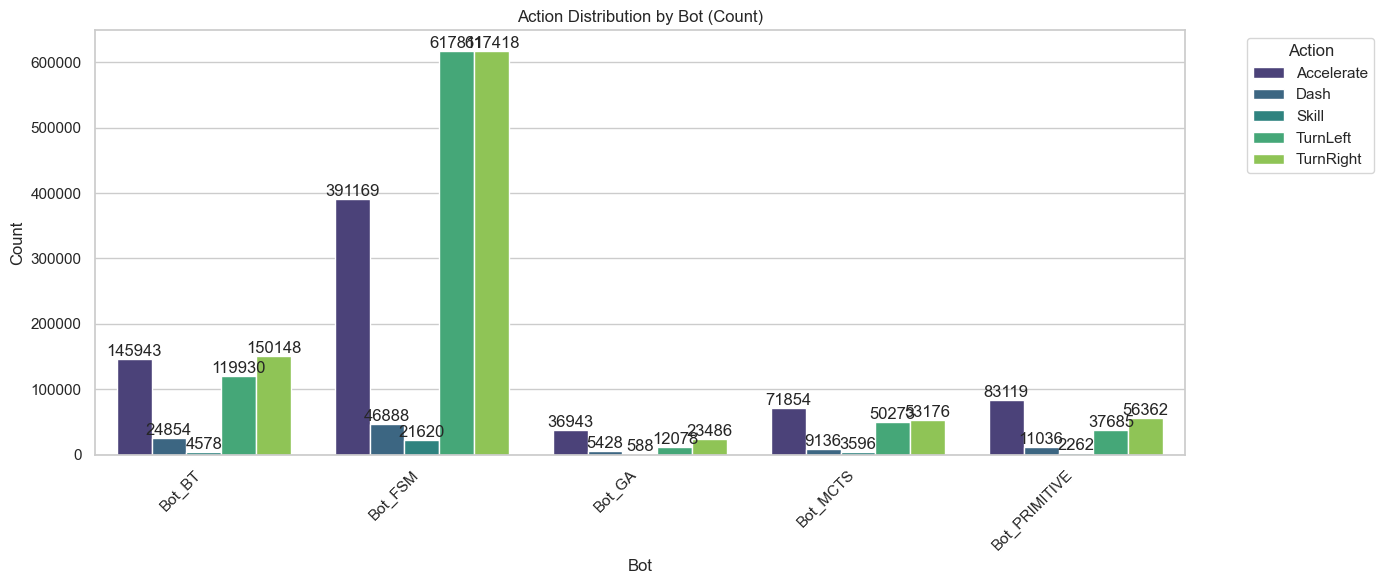

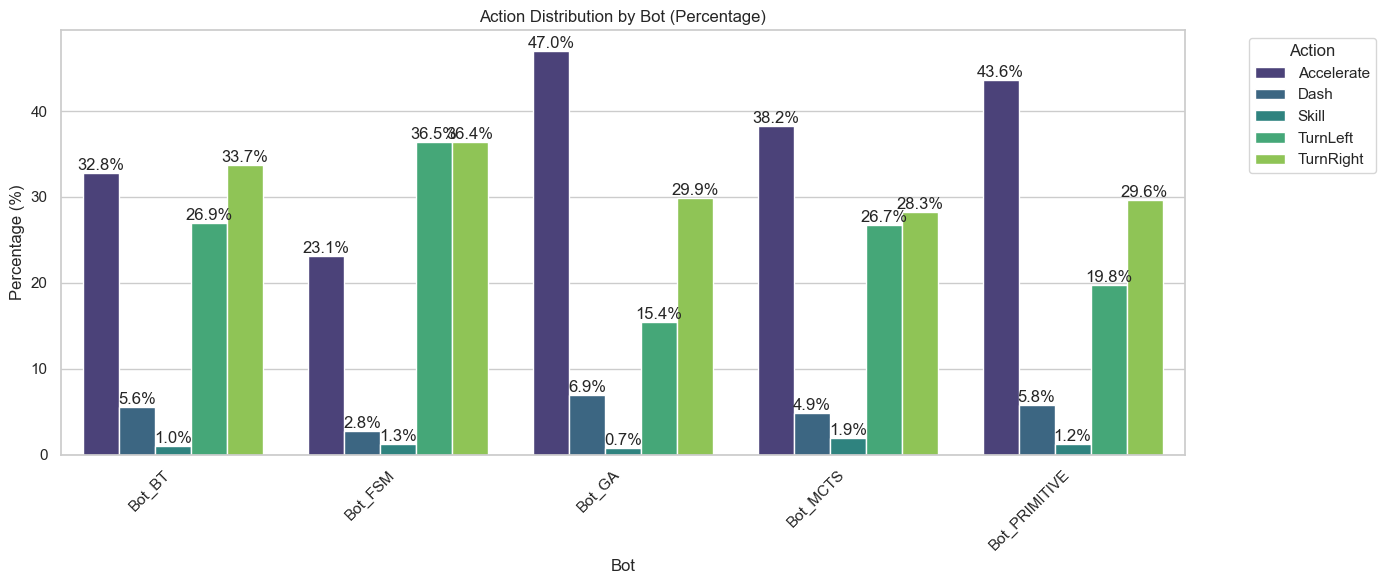

In [8]:
# Action Distribution Analysis
# Updated to work with simulation CSV format

if 'merged_df' not in locals():
    # Try to load from saved file
    if os.path.exists(MERGED_CSV):
        merged_df = pd.read_csv(MERGED_CSV)
        print(f"✓ Loaded {len(merged_df):,} records from {MERGED_CSV}")
    else:
        print("❌ merged_df not found. Please run cells 2-4 first.")

if 'merged_df' in locals():
    # Get all unique bots from the data
    unique_left = set(merged_df["Meta_LeftBot"].unique())
    unique_right = set(merged_df["Meta_RightBot"].unique())
    target_bots = sorted(unique_left | unique_right)
    
    print(f"Analyzing action distribution for: {target_bots}\n")
    
    # Action mapping - adjust based on your action names
    # Check what actions exist in your data from previous cell output
    action_mapping = {
        "TurnLeft": "TurnLeft",
        "TurnRight": "TurnRight",
        "Dash": "Dash",
        "SkillBoost": "Skill",
        "SkillStone": "Skill",
        # Add any other action mappings as needed
    }

    # Filter for actions performed by target bots
    actions_list = []

    # Process Left Actors
    mask_left = (merged_df["Event_Actor"] == "Left")
    df_left = merged_df.loc[mask_left, ["Meta_LeftBot", "Event_Data_Name"]].copy()
    df_left.columns = ["BotType", "Action"]
    actions_list.append(df_left)

    # Process Right Actors
    mask_right = (merged_df["Event_Actor"] == "Right")
    df_right = merged_df.loc[mask_right, ["Meta_RightBot", "Event_Data_Name"]].copy()
    df_right.columns = ["BotType", "Action"]
    actions_list.append(df_right)

    # Combine
    if actions_list:
        df_actions = pd.concat(actions_list, ignore_index=True)
        
        # Show raw action counts before mapping
        print("=== Raw Action Counts ===")
        print(df_actions["Action"].value_counts())
        print()

        # Map actions (only if mapping dict is not empty)
        if action_mapping:
            df_actions["Action_Mapped"] = df_actions["Action"].map(action_mapping)
            # Keep unmapped actions as-is
            df_actions["Action_Final"] = df_actions["Action_Mapped"].fillna(df_actions["Action"])
        else:
            df_actions["Action_Final"] = df_actions["Action"]
        
        # Remove NaN actions
        df_actions = df_actions.dropna(subset=["Action_Final"])
        
        # Get unique actions for ordering
        action_order = sorted(df_actions["Action_Final"].unique())
        bot_order = target_bots

        # 1. Plot Raw Counts
        plt.figure(figsize=(14, 6))
        ax1 = sns.countplot(data=df_actions, x="BotType", hue="Action_Final", palette="viridis", 
                            hue_order=action_order, order=bot_order)
        plt.title("Action Distribution by Bot (Count)")
        plt.xlabel("Bot")
        plt.ylabel("Count")
        plt.legend(title="Action", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        
        # Add labels to bars
        for container in ax1.containers:
            ax1.bar_label(container, fmt='%d')
            
        plt.tight_layout()
        plt.show()

        # 2. Plot Normalized Distribution (Percentage)
        action_counts = df_actions.groupby(['BotType', 'Action_Final']).size().reset_index(name='Count')
        total_counts = df_actions.groupby('BotType').size().reset_index(name='Total')
        action_counts = action_counts.merge(total_counts, on='BotType')
        action_counts['Percentage'] = action_counts['Count'] / action_counts['Total'] * 100

        plt.figure(figsize=(14, 6))
        ax2 = sns.barplot(data=action_counts, x="BotType", y="Percentage", hue="Action_Final", palette="viridis", 
                          hue_order=action_order, order=bot_order)
        plt.title("Action Distribution by Bot (Percentage)")
        plt.xlabel("Bot")
        plt.ylabel("Percentage (%)")
        plt.legend(title="Action", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        
        # Add labels to bars
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.1f%%')
            
        plt.tight_layout()
        plt.show()
    else:
        print("❌ No actions found for the target bots.")
else:
    print("❌ Dataframe not available.")

Games Played per Bot: {'Bot_BT': 4, 'Bot_FSM': 5, 'Bot_GA': 1, 'Bot_MCTS': 4, 'Bot_PRIMITIVE': 2}


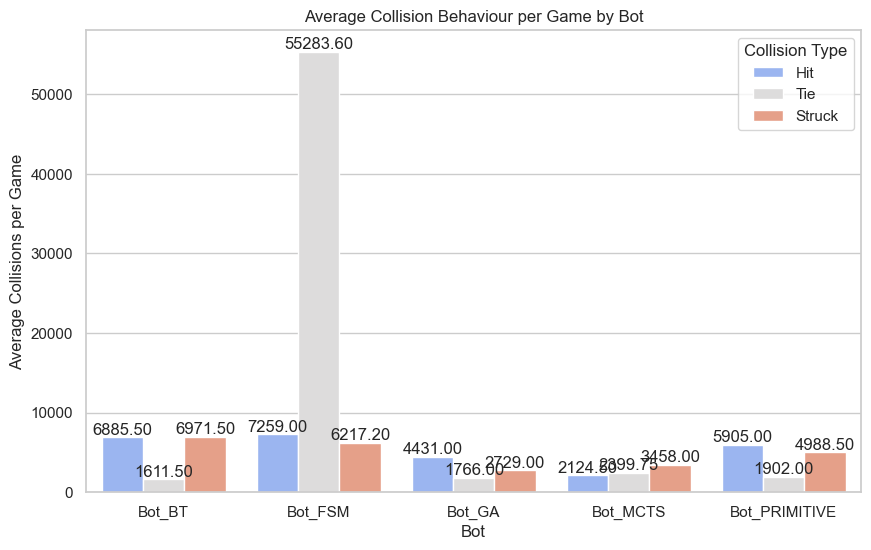

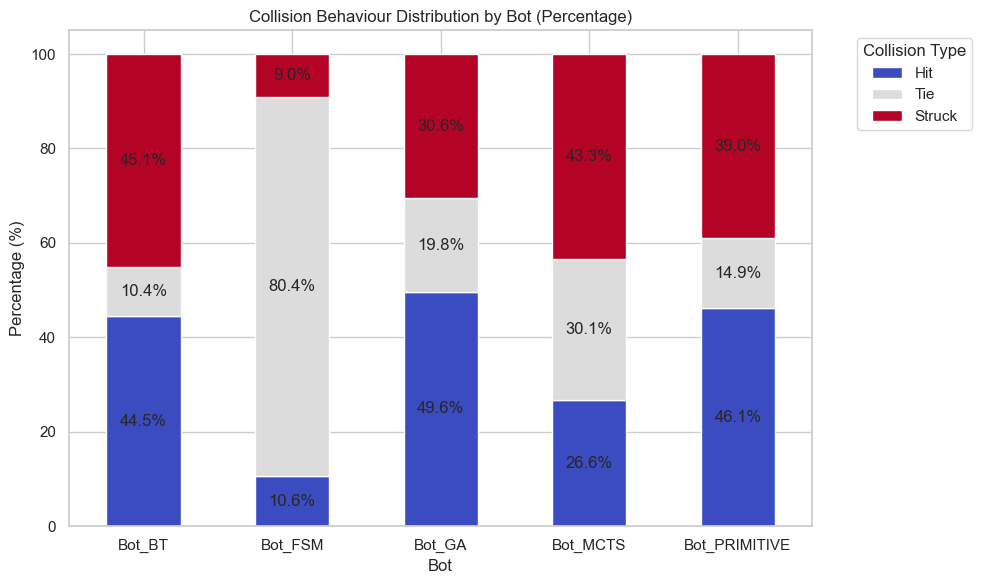

          BotName CollisionType  TotalCount  AveragePerGame
0          Bot_BT           Hit       27542         6885.50
1          Bot_BT        Struck       27886         6971.50
2          Bot_BT           Tie        6446         1611.50
3         Bot_FSM           Hit       36295         7259.00
4         Bot_FSM        Struck       31086         6217.20
5         Bot_FSM           Tie      276418        55283.60
6          Bot_GA           Hit        4431         4431.00
7          Bot_GA        Struck        2729         2729.00
8          Bot_GA           Tie        1766         1766.00
9        Bot_MCTS           Hit        8498         2124.50
10       Bot_MCTS        Struck       13832         3458.00
11       Bot_MCTS           Tie        9599         2399.75
12  Bot_PRIMITIVE           Hit       11810         5905.00
13  Bot_PRIMITIVE        Struck        9977         4988.50
14  Bot_PRIMITIVE           Tie        3804         1902.00


In [9]:
# Collision Behaviour Analysis
if 'merged_df' in locals():
    # Check if we have the necessary velocity columns
    if "Robot_LinearVelocity" not in merged_df.columns:
        print("⚠️ Missing 'Robot_LinearVelocity' column.")
        print("Please re-run the 'Process all folders' cell (it has been updated to extract velocity) and then re-run the 'Merge' cell.")
    else:
        # Filter for Collision events involving target bots
        # target_bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"]
        
        # 1. Calculate Total Games per Bot to compute averages
        # Each folder represents one game
        unique_games = merged_df.drop_duplicates(subset=["Folder"])
        games_played = {bot: 0 for bot in target_bots}
        
        for _, row in unique_games.iterrows():
            if row["Meta_LeftBot"] in games_played:
                games_played[row["Meta_LeftBot"]] += 1
            if row["Meta_RightBot"] in games_played:
                games_played[row["Meta_RightBot"]] += 1
                
        print("Games Played per Bot:", games_played)
        
        # We want events where the Category is Collision and Actor is Left or Right
        mask = (merged_df["Event_Category"] == "Collision") & \
               (merged_df["Event_Actor"].isin(["Left", "Right"]))
        
        df_coll = merged_df[mask].copy()
        
        # Map Actor to BotName
        def get_bot_name(row):
            if row["Event_Actor"] == "Left": return row["Meta_LeftBot"]
            if row["Event_Actor"] == "Right": return row["Meta_RightBot"]
            return "Unknown"
            
        df_coll["BotName"] = df_coll.apply(get_bot_name, axis=1)
        
        # Filter for target bots
        df_coll = df_coll[df_coll["BotName"].isin(target_bots)]
        
        if df_coll.empty:
            print("No collision events found for target bots.")
        else:
            # Determine Collision Type
            # Hit: Actor Vel > Enemy Vel
            # Struck: Actor Vel < Enemy Vel
            # Tie: Equal or missing info
            
            def get_collision_type(row):
                v_actor = row.get("Robot_LinearVelocity")
                v_enemy = row.get("EnemyRobot_LinearVelocity")
                
                if pd.isna(v_actor) or pd.isna(v_enemy):
                    return "Tie" 
                
                # Use a small epsilon for float comparison
                if v_actor > v_enemy + 0.001:
                    return "Hit"
                elif v_actor < v_enemy - 0.001:
                    return "Struck"
                else:
                    return "Tie"
                    
            df_coll["CollisionType"] = df_coll.apply(get_collision_type, axis=1)
            
            # Calculate Totals
            collision_stats = df_coll.groupby(['BotName', 'CollisionType']).size().reset_index(name='TotalCount')
            
            # Calculate Averages
            def calculate_average(row):
                bot = row['BotName']
                total = row['TotalCount']
                n_games = games_played.get(bot, 0)
                return total / n_games if n_games > 0 else 0
                
            collision_stats['AveragePerGame'] = collision_stats.apply(calculate_average, axis=1)
            
            # 1. Plot Average Counts
            plt.figure(figsize=(10, 6))
            ax = sns.barplot(data=collision_stats, x="BotName", y="AveragePerGame", hue="CollisionType", palette="coolwarm", hue_order=["Hit", "Tie", "Struck"])
            plt.title("Average Collision Behaviour per Game by Bot")
            plt.xlabel("Bot")
            plt.ylabel("Average Collisions per Game")
            plt.legend(title="Collision Type")
            
            # Add labels
            for container in ax.containers:
                ax.bar_label(container, fmt='%.2f')
                
            plt.show()

            # 2. Plot Normalized Stacked Bar (Percentage)
            # Pivot for stacking
            collision_pivot = collision_stats.pivot(index='BotName', columns='CollisionType', values='TotalCount').fillna(0)
            
            # Calculate percentages
            collision_pct = collision_pivot.div(collision_pivot.sum(axis=1), axis=0) * 100
            
            # Reorder columns if they exist
            cols_order = [c for c in ["Hit", "Tie", "Struck"] if c in collision_pct.columns]
            collision_pct = collision_pct[cols_order]
            
            # Plot
            ax2 = collision_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
            plt.title("Collision Behaviour Distribution by Bot (Percentage)")
            plt.xlabel("Bot")
            plt.ylabel("Percentage (%)")
            plt.legend(title="Collision Type", bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.xticks(rotation=0)
            
            # Add labels
            for c in ax2.containers:
                ax2.bar_label(c, fmt='%.1f%%', label_type='center')
                
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(collision_stats)
        
else:
    print("merged_df not found. Please run the merge cell first.")

Analyzed 42 rounds.
Bots: ['Bot_BT', 'Bot_FSM', 'Bot_GA', 'Bot_MCTS', 'Bot_PRIMITIVE']

Round duration stats:
count    42.000000
mean     49.505741
std      16.155868
min      27.619247
25%      37.620960
50%      42.610118
75%      61.494137
max      89.841490
Name: RoundDuration, dtype: float64


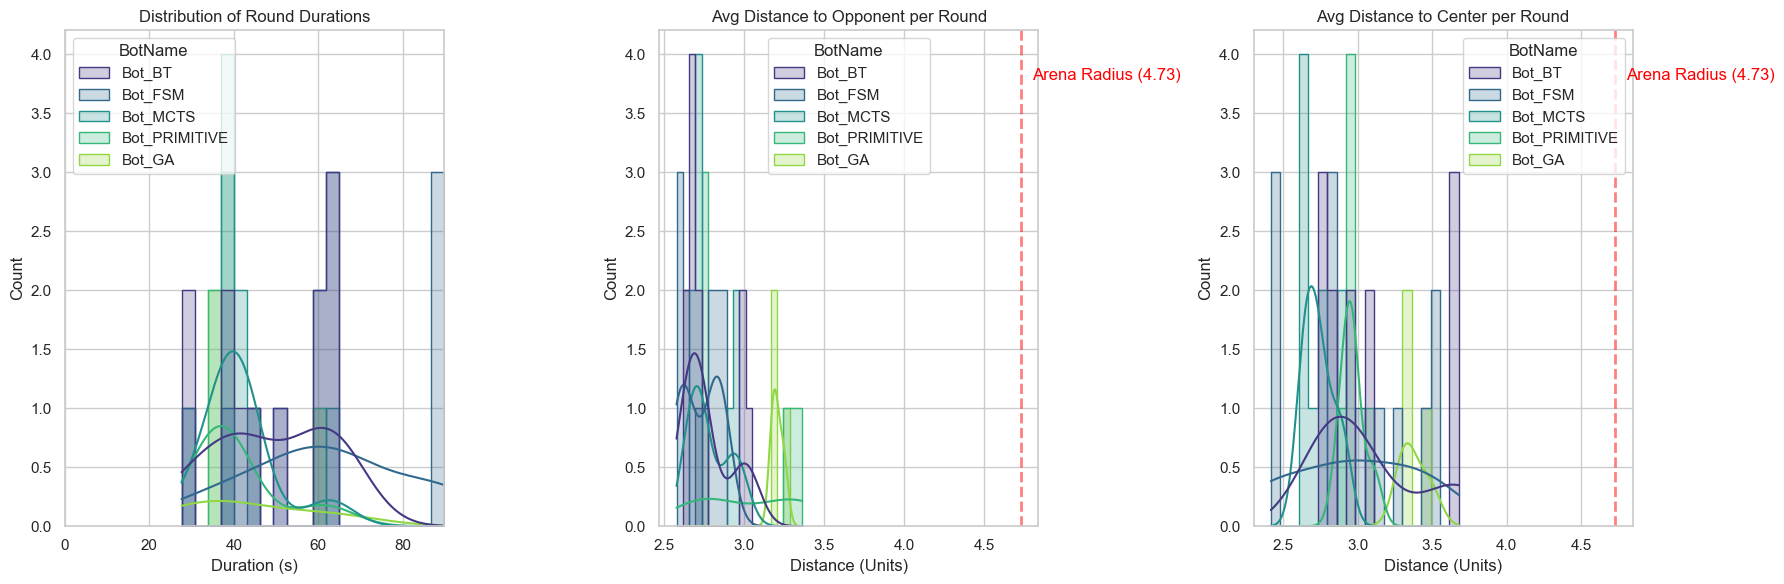

In [10]:
# Spatial and Temporal Analysis
if 'merged_df' in locals():
    # Check for necessary columns
    required_cols = ["Robot_PosX", "Robot_PosY", "EnemyRobot_PosX", "EnemyRobot_PosY"]
    missing_cols = [c for c in required_cols if c not in merged_df.columns]
    
    if missing_cols:
        print(f"⚠️ Missing columns: {missing_cols}")
        print("Please re-run the column mapping cell (Cell 4).")
    else:
        # Get all unique bots
        unique_left = set(merged_df["Meta_LeftBot"].unique())
        unique_right = set(merged_df["Meta_RightBot"].unique())
        target_bots = sorted(unique_left | unique_right)
        
        # Filter for target bots
        # Case A: Actor is Left, and LeftBot is Target
        mask_left = (merged_df["Event_Actor"] == "Left")
        df_left = merged_df[mask_left].copy()
        df_left["BotName"] = df_left["Meta_LeftBot"]
        
        # Case B: Actor is Right, and RightBot is Target
        mask_right = (merged_df["Event_Actor"] == "Right")
        df_right = merged_df[mask_right].copy()
        df_right["BotName"] = df_right["Meta_RightBot"]
        
        df_spatial = pd.concat([df_left, df_right])
        
        # Calculate Distances
        # Distance to Center (0,0)
        df_spatial["DistToCenter"] = (df_spatial["Robot_PosX"]**2 + df_spatial["Robot_PosY"]**2)**0.5
        
        # Distance to Enemy
        df_spatial["DistToEnemy"] = ((df_spatial["Robot_PosX"] - df_spatial["EnemyRobot_PosX"])**2 + 
                                     (df_spatial["Robot_PosY"] - df_spatial["EnemyRobot_PosY"])**2)**0.5
        
        # Check if RoundDuration exists, if not calculate it
        if "RoundDuration" not in df_spatial.columns:
            print("⚠️ RoundDuration column missing, calculating from Event_UpdatedAt...")
            round_dur = df_spatial.groupby(["Folder", "RoundIndex"])["Event_UpdatedAt"].max().reset_index()
            round_dur.columns = ["Folder", "RoundIndex", "RoundDuration"]
            df_spatial = df_spatial.merge(round_dur, on=["Folder", "RoundIndex"], how="left")
        
        # Group by Round to get Averages per Round
        round_stats = df_spatial.groupby(["Folder", "RoundIndex", "BotName"]).agg({
            "DistToCenter": "mean",
            "DistToEnemy": "mean",
            "RoundDuration": "first" 
        }).reset_index()
        
        # Remove any NaN durations
        round_stats = round_stats.dropna(subset=["RoundDuration"])
        
        print(f"Analyzed {len(round_stats)} rounds.")
        print(f"Bots: {sorted(round_stats['BotName'].unique())}")
        print(f"\nRound duration stats:")
        print(round_stats["RoundDuration"].describe())
        
        if len(round_stats) < 2:
            print("\n⚠️ Not enough data for plotting (need at least 2 rounds)")
        else:
            # Plotting
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            # 1. Round Duration Distribution
            try:
                sns.histplot(data=round_stats, x="RoundDuration", hue="BotName", kde=True, 
                           element="step", ax=axes[0], palette="viridis", bins=20)
                axes[0].set_title("Distribution of Round Durations")
                axes[0].set_xlabel("Duration (s)")
                axes[0].set_xlim(0, max(60, round_stats["RoundDuration"].max()))
            except Exception as e:
                print(f"⚠️ Could not plot duration distribution: {e}")
                axes[0].text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', transform=axes[0].transAxes)
            
            # 2. Average Distance to Enemy
            try:
                sns.histplot(data=round_stats, x="DistToEnemy", hue="BotName", kde=True, 
                           element="step", ax=axes[1], palette="viridis", bins=20)
                axes[1].axvline(x=4.73, color='red', linestyle='--', linewidth=2, alpha=0.5)
                axes[1].text(4.8, 0.9, 'Arena Radius (4.73)', color='red', transform=axes[1].get_xaxis_transform())
                axes[1].set_title("Avg Distance to Opponent per Round")
                axes[1].set_xlabel("Distance (Units)")
            except Exception as e:
                print(f"⚠️ Could not plot enemy distance: {e}")
                axes[1].text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', transform=axes[1].transAxes)
            
            # 3. Average Distance to Center
            try:
                sns.histplot(data=round_stats, x="DistToCenter", hue="BotName", kde=True, 
                           element="step", ax=axes[2], palette="viridis", bins=20)
                axes[2].axvline(x=4.73, color='red', linestyle='--', linewidth=2, alpha=0.5)
                axes[2].text(4.8, 0.9, 'Arena Radius (4.73)', color='red', transform=axes[2].get_xaxis_transform())
                axes[2].set_title("Avg Distance to Center per Round")
                axes[2].set_xlabel("Distance (Units)")
            except Exception as e:
                print(f"⚠️ Could not plot center distance: {e}")
                axes[2].text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', transform=axes[2].transAxes)
            
            plt.tight_layout()
            plt.show()
        
else:
    print("merged_df not found. Please run the merge cell first.")

--- Position Distributions (Time > 2.5s) ---


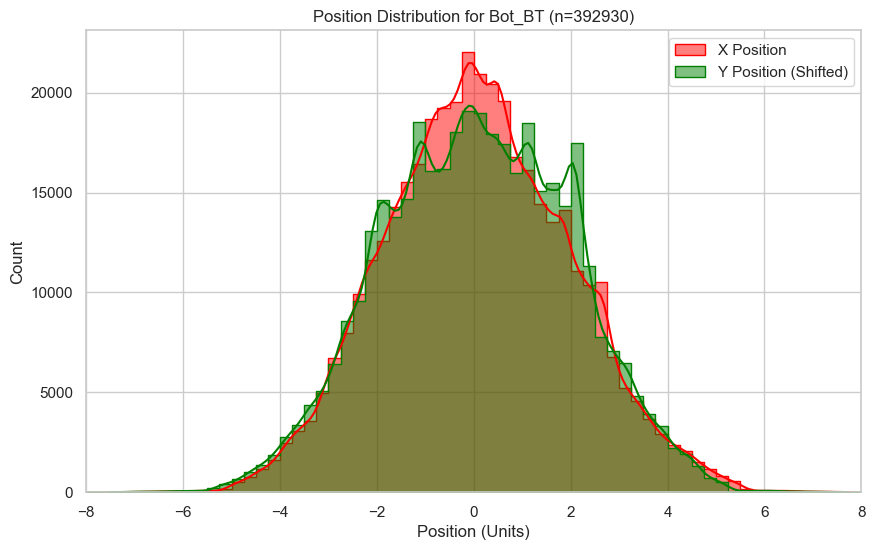

Bot_BT: 392930 samples


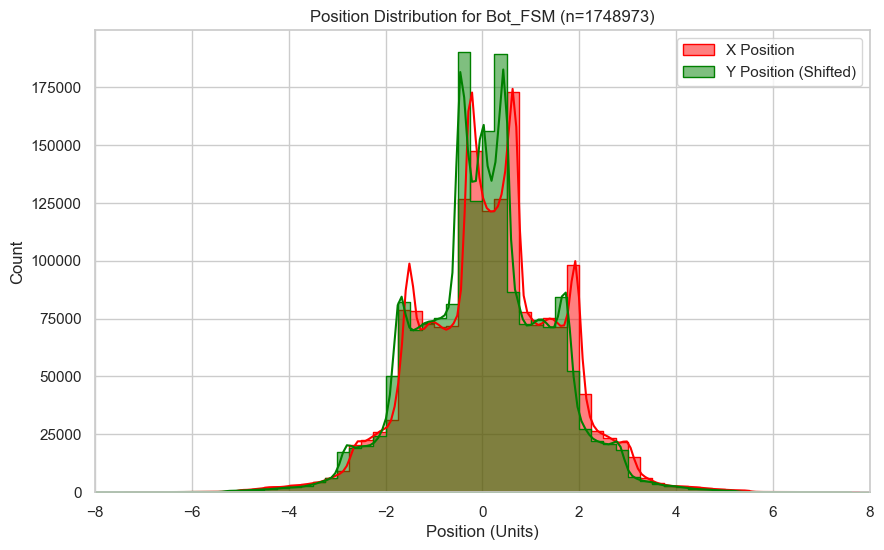

Bot_FSM: 1748973 samples


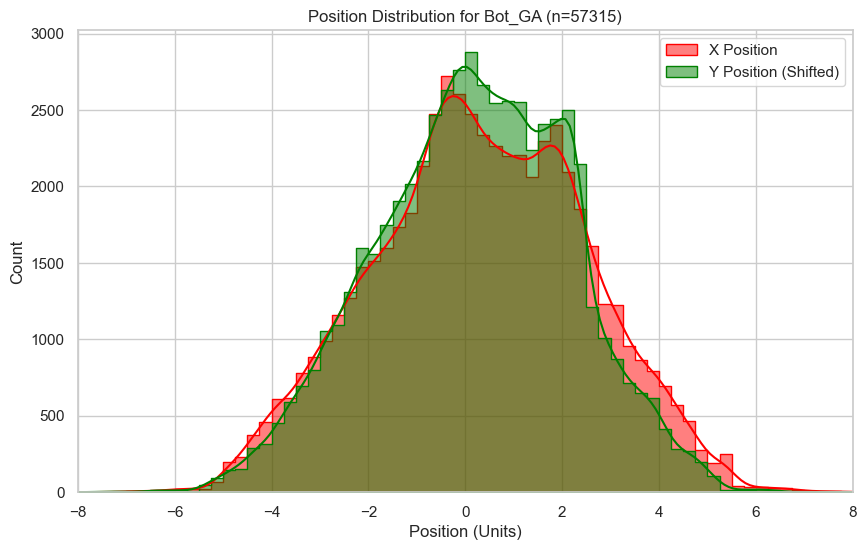

Bot_GA: 57315 samples


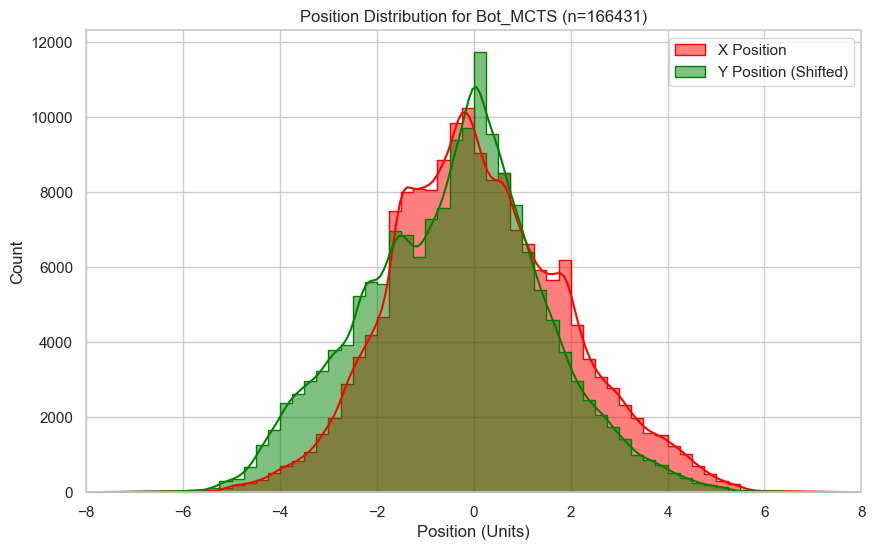

Bot_MCTS: 166431 samples


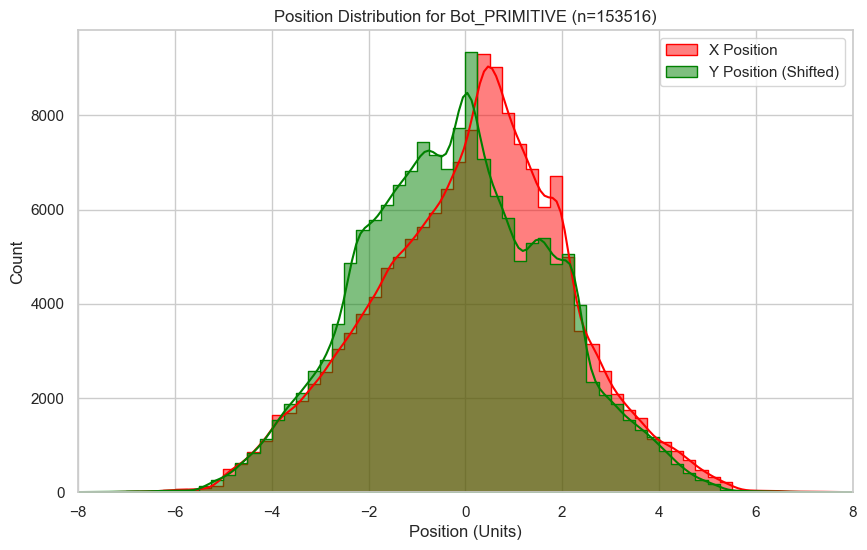

Bot_PRIMITIVE: 153516 samples


In [11]:
# Position Distribution Analysis
if 'merged_df' in locals():
    # Check for necessary columns
    required_cols = ["Robot_PosX", "Robot_PosY", "Event_StartedAt", "Folder", "RoundIndex"]
    missing_cols = [c for c in required_cols if c not in merged_df.columns]
    
    if missing_cols:
        print(f"⚠️ Missing columns: {missing_cols}")
        print("Please re-run the 'Process all folders' cell and then 'Merge' cell.")
    else:
        
        # 1. Prepare Data
        # Filter for target bots (Left and Right)
        mask_left = (merged_df["Event_Actor"] == "Left") & (merged_df["Meta_LeftBot"].isin(target_bots))
        df_left = merged_df[mask_left].copy()
        df_left["BotName"] = df_left["Meta_LeftBot"]
        
        mask_right = (merged_df["Event_Actor"] == "Right") & (merged_df["Meta_RightBot"].isin(target_bots))
        df_right = merged_df[mask_right].copy()
        df_right["BotName"] = df_right["Meta_RightBot"]
        
        df_pos = pd.concat([df_left, df_right])
        
        # Ensure sorted by time to find initial position correctly
        df_pos = df_pos.sort_values(["Folder", "RoundIndex", "BotName", "Event_StartedAt"])
        
        # Calculate Initial Y Position for each round to shift Y
        # We group by Round and take the first Robot_PosY
        start_y = df_pos.groupby(["Folder", "RoundIndex", "BotName"])["Robot_PosY"].first().reset_index()
        start_y.rename(columns={"Robot_PosY": "StartY"}, inplace=True)
        
        # Merge back
        df_pos = df_pos.merge(start_y, on=["Folder", "RoundIndex", "BotName"])
        
        # Apply Shift: Y_new = Y_old - Y_start
        # This makes the starting Y position 0 for all rounds
        df_pos["PosY_Shifted"] = df_pos["Robot_PosY"] - df_pos["StartY"]
        
        # Filter out first 2.5 seconds
        df_filtered = df_pos[df_pos["Event_StartedAt"] > 2.5].copy()
        
        # --- Analysis 1: Distribution of X and Y (Shifted) ---
        print("--- Position Distributions (Time > 2.5s) ---")
        
        # Consistent bins and range
        plot_range = (-8, 8)
        n_bins = 64 
        
        for bot in target_bots:
            bot_data = df_filtered[df_filtered["BotName"] == bot]
            sample_size = len(bot_data)
            
            plt.figure(figsize=(10, 6))
            
            # Plot X (Red)
            sns.histplot(data=bot_data, x="Robot_PosX", color="red", alpha=0.5, label="X Position", kde=True, element="step", binrange=plot_range, bins=n_bins)
            
            # Plot Y Shifted (Green)
            sns.histplot(data=bot_data, x="PosY_Shifted", color="green", alpha=0.5, label="Y Position (Shifted)", kde=True, element="step", binrange=plot_range, bins=n_bins)
            
            plt.title(f"Position Distribution for {bot} (n={sample_size})")
            plt.xlabel("Position (Units)")
            plt.ylabel("Count")
            plt.xlim(plot_range)
            plt.legend()
            plt.show()
            
            print(f"{bot}: {sample_size} samples")
else:
    print("merged_df not found. Please run the merge cell first.")

--- Spatiotemporal Heatmaps ---

Generating Heatmaps for Bot_BT...
  Window 2.5-15s: n=309010


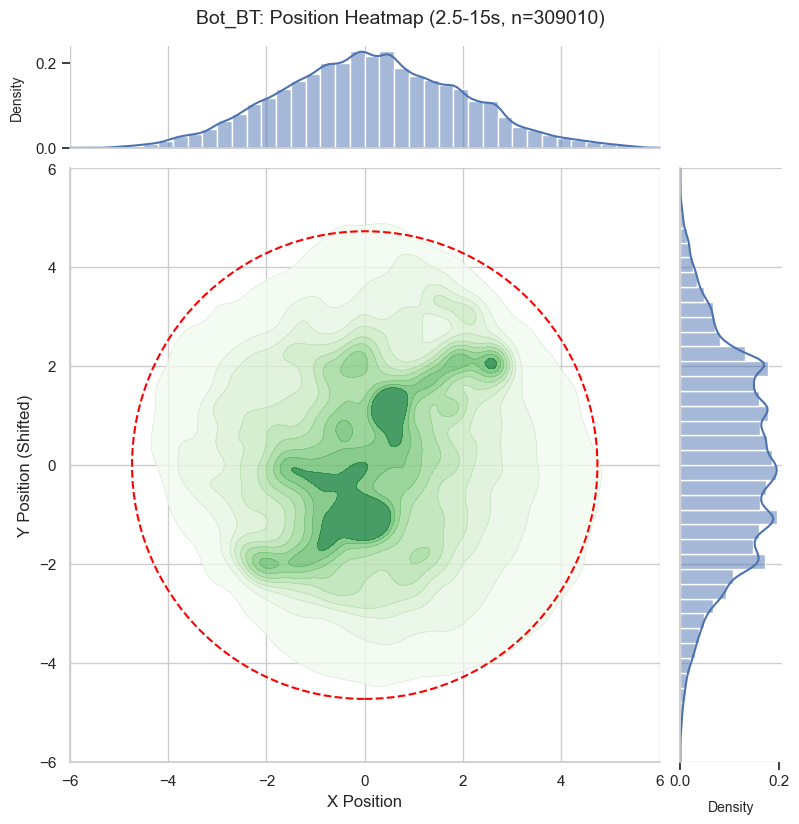

  Window 15-30s: n=61500


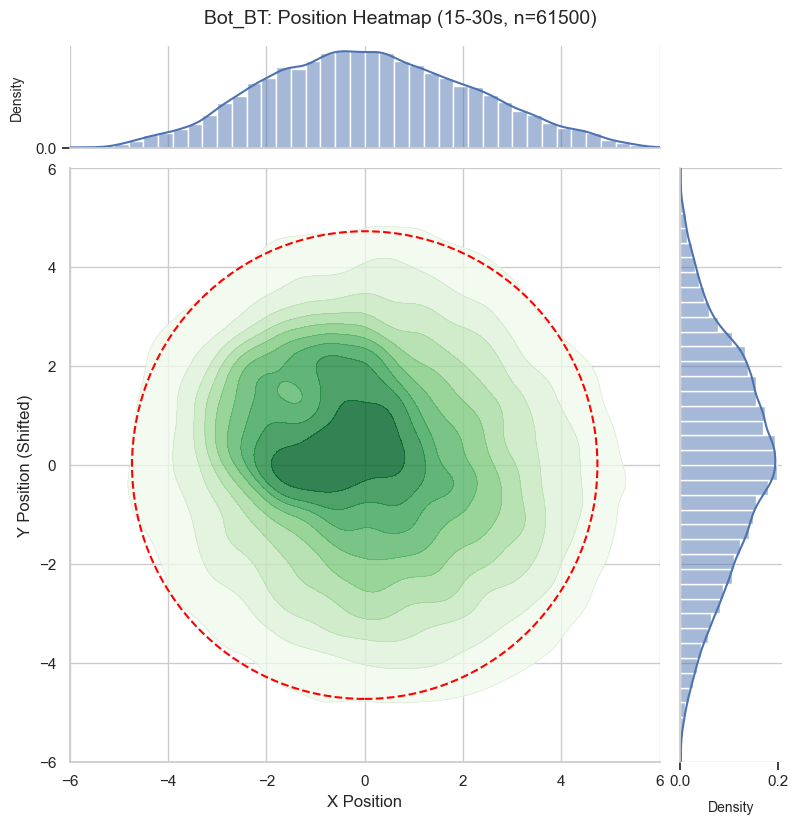

  Window 30-45s: n=14263


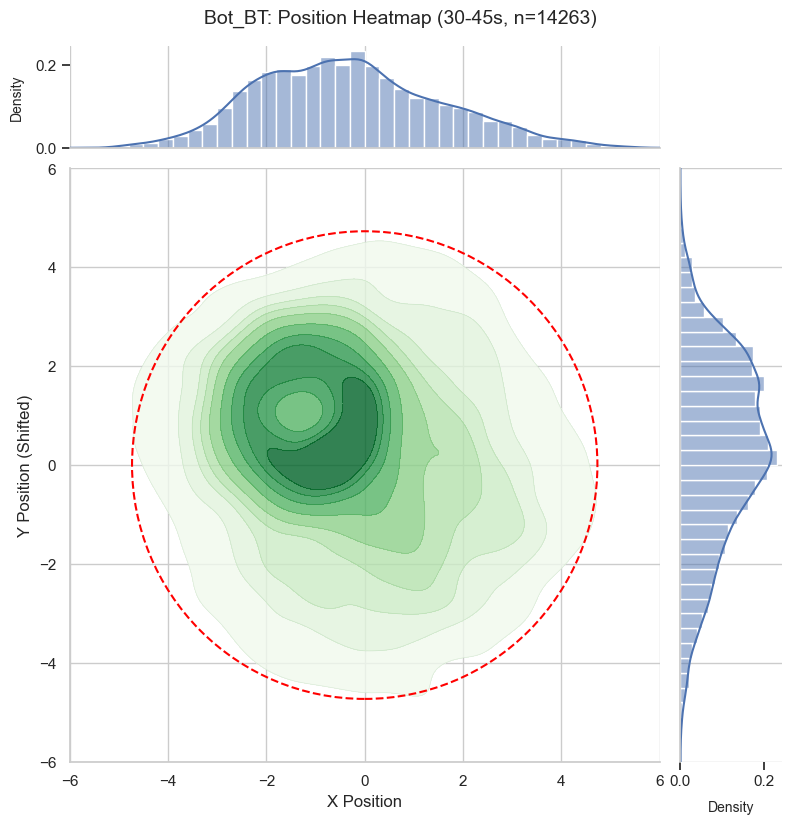

  Window 45-60s: n=6887


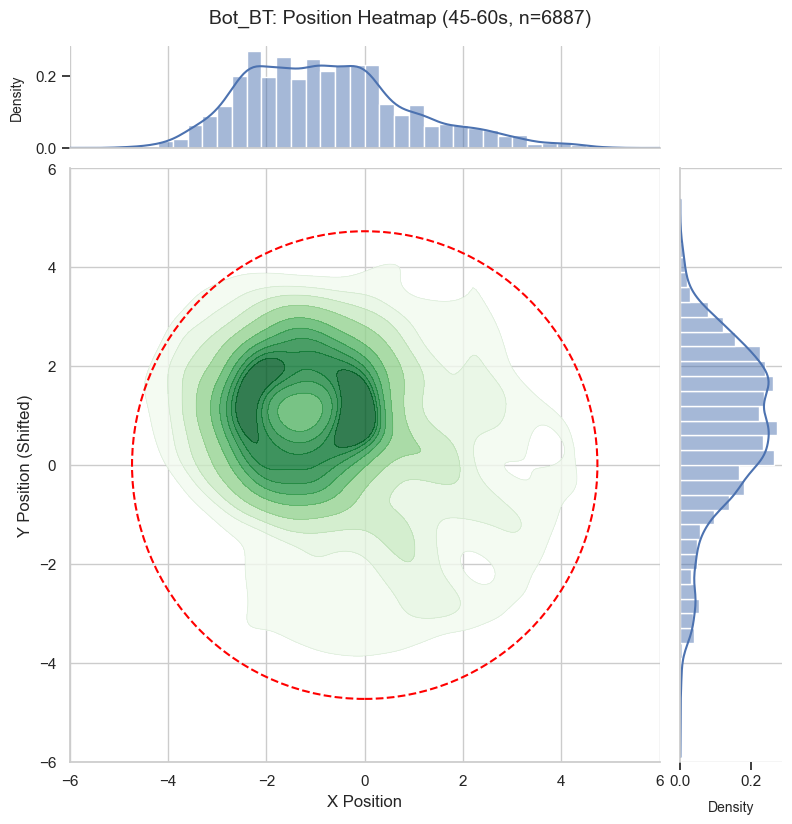


Generating Heatmaps for Bot_FSM...
  Window 2.5-15s: n=570790


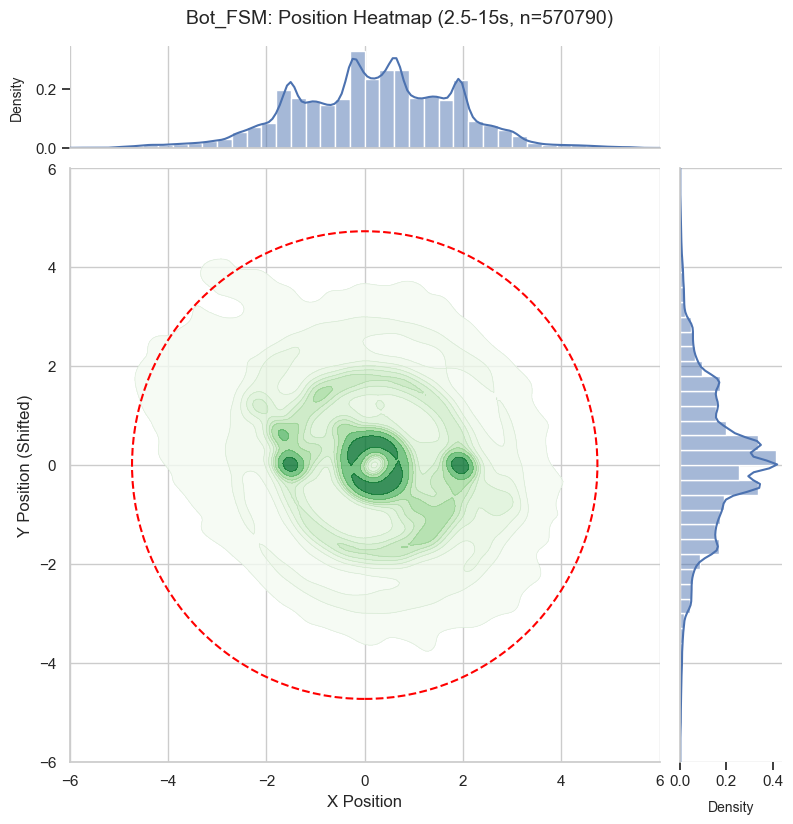

  Window 15-30s: n=425641


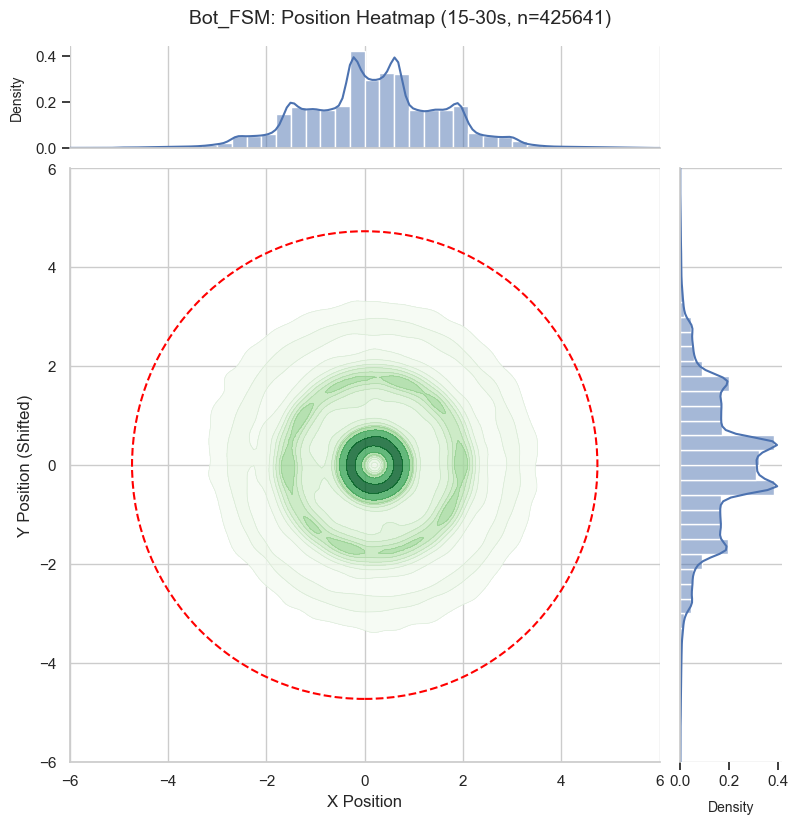

  Window 30-45s: n=355033


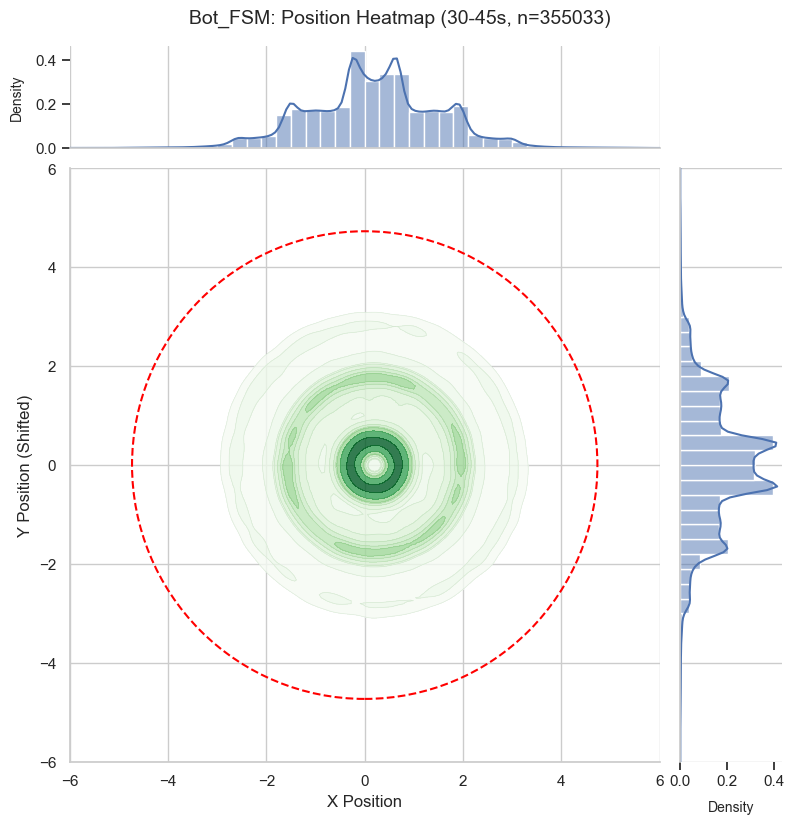

  Window 45-60s: n=317963


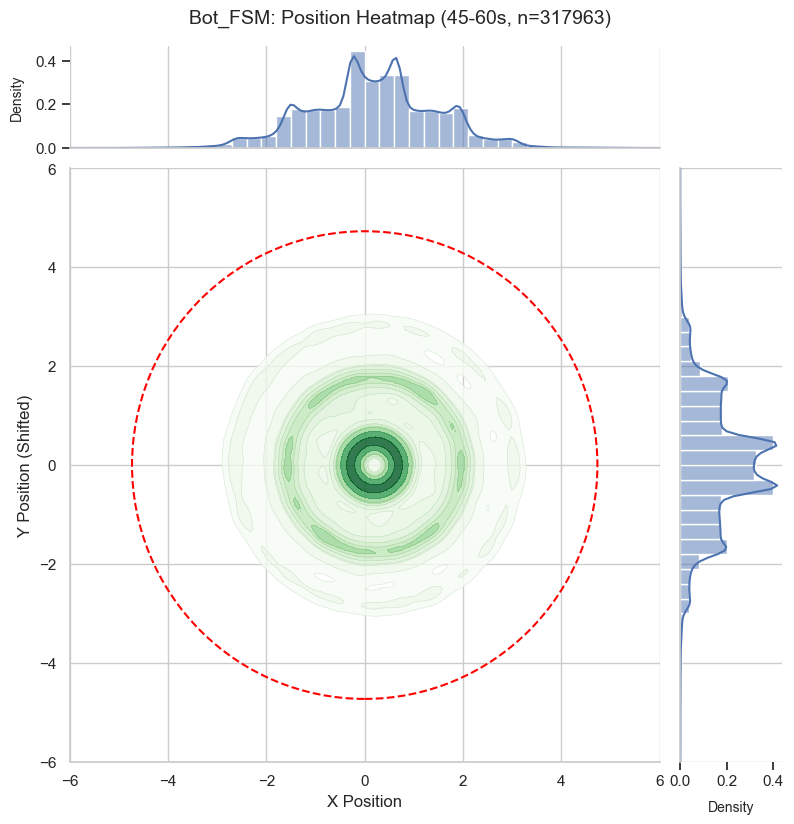


Generating Heatmaps for Bot_GA...
  Window 2.5-15s: n=52677


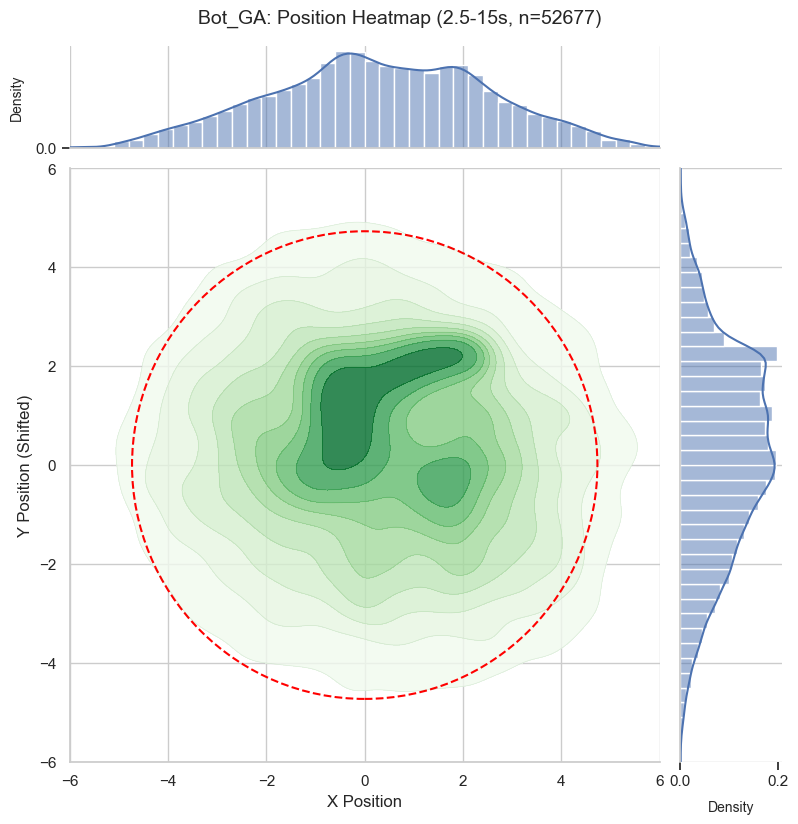

  Window 15-30s: n=3951


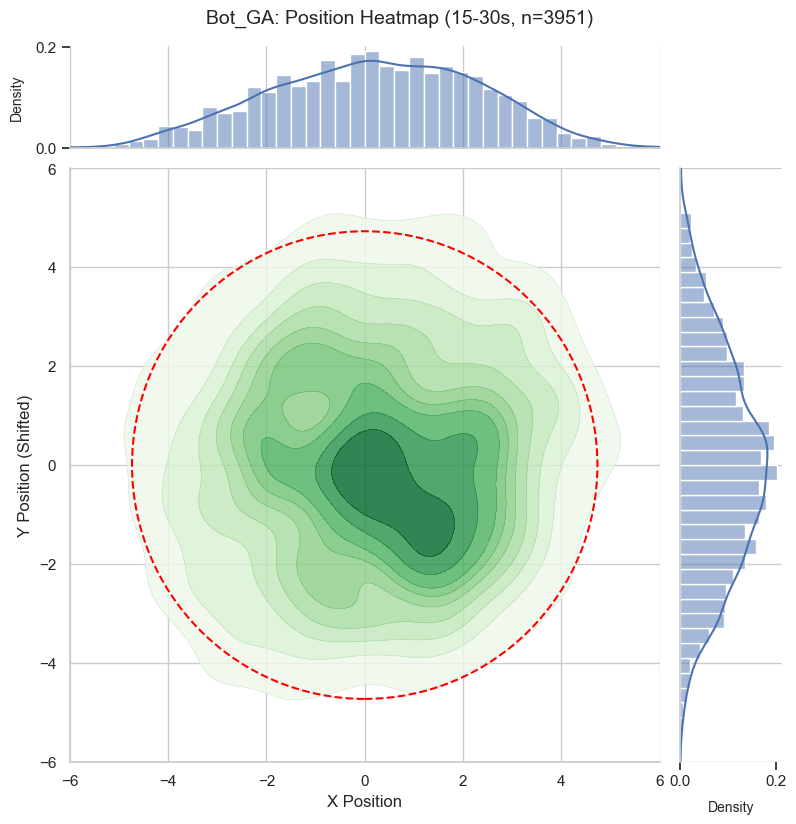

  Window 30-45s: n=409


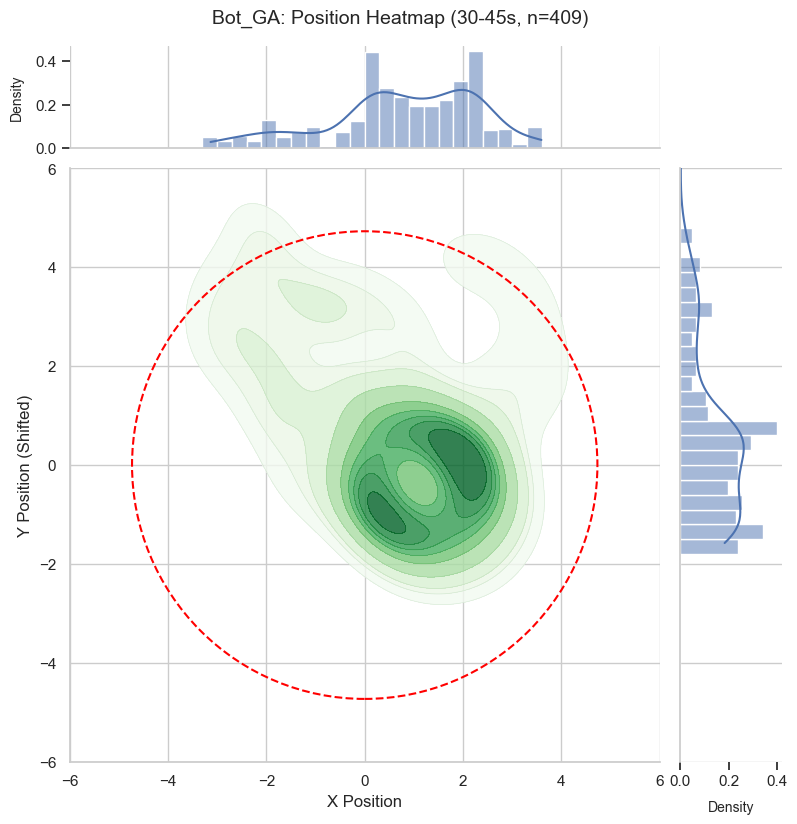

  Window 45-60s: n=251


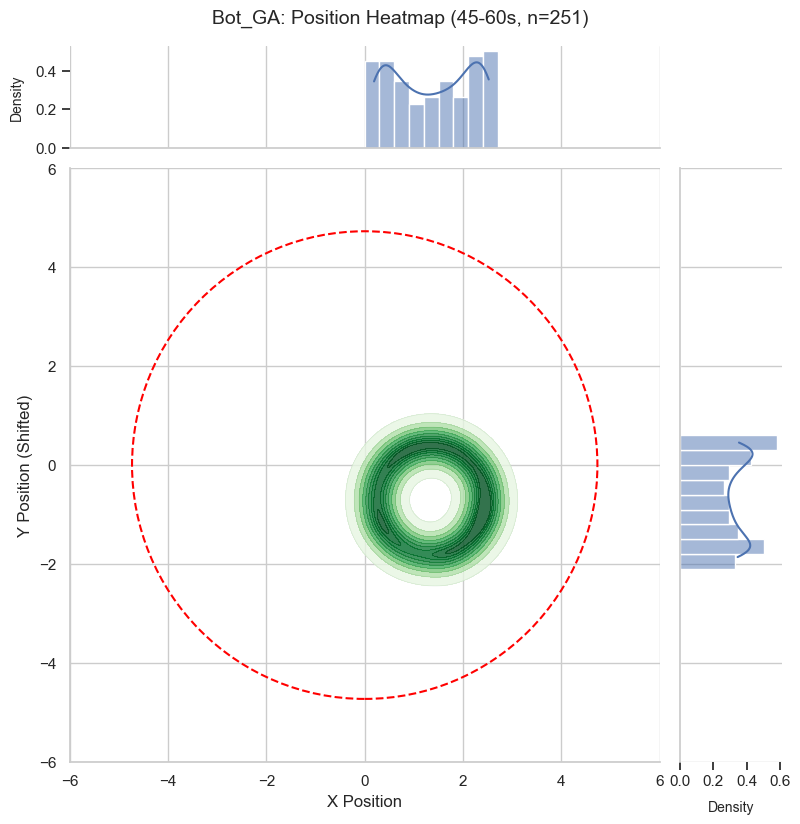


Generating Heatmaps for Bot_MCTS...
  Window 2.5-15s: n=138698


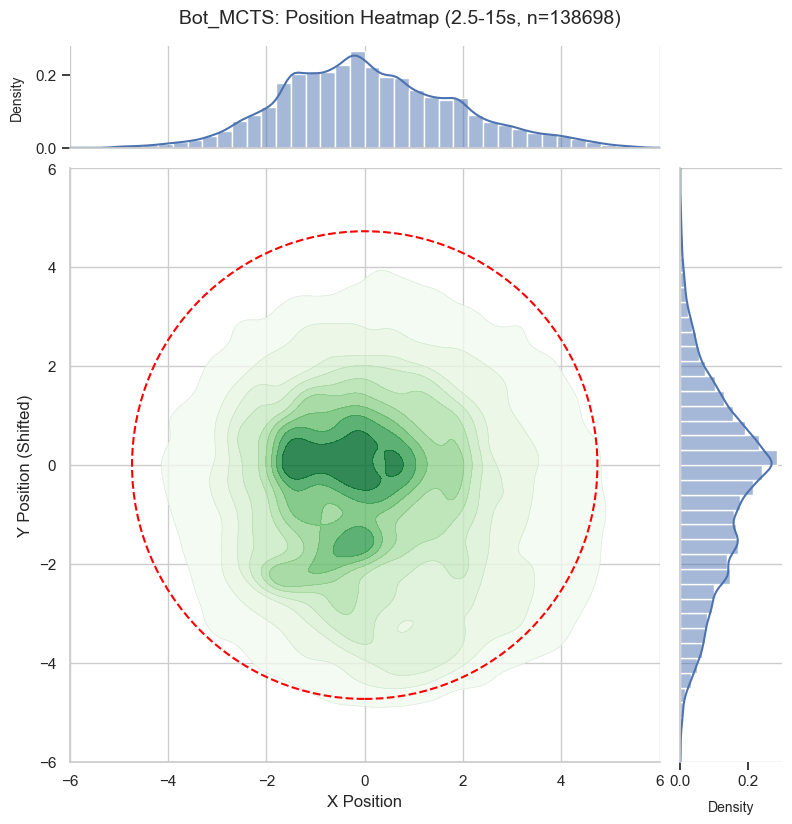

  Window 15-30s: n=25157


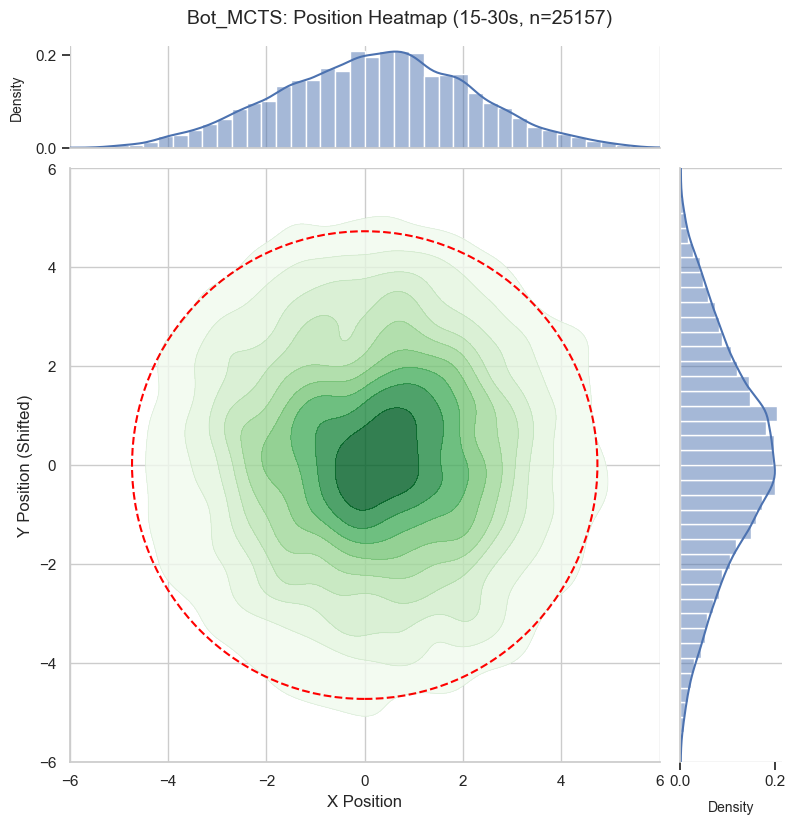

  Window 30-45s: n=2479


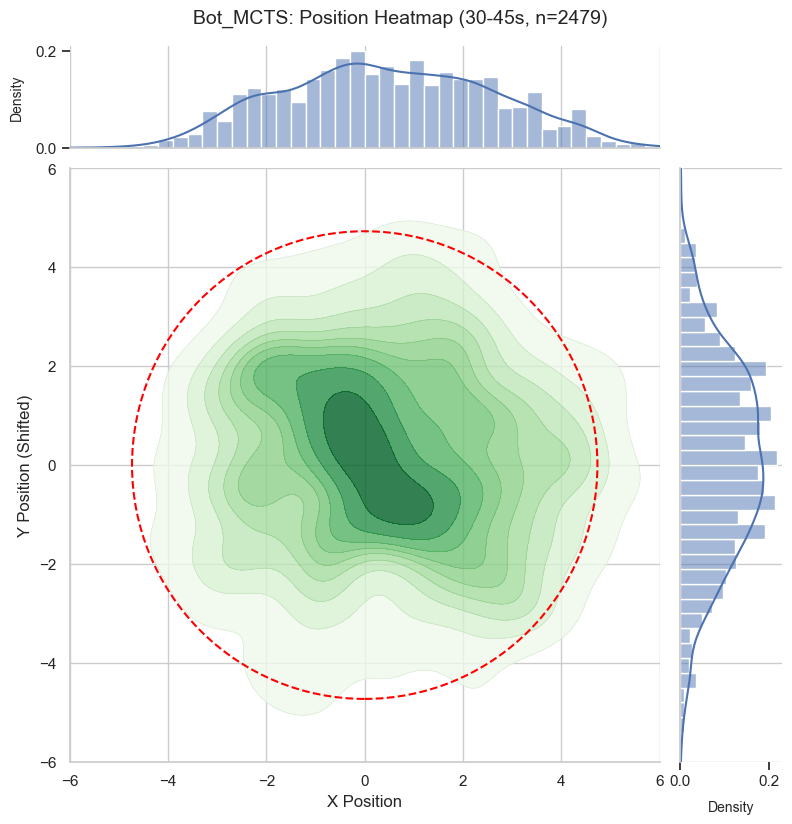

  Window 45-60s: n=93


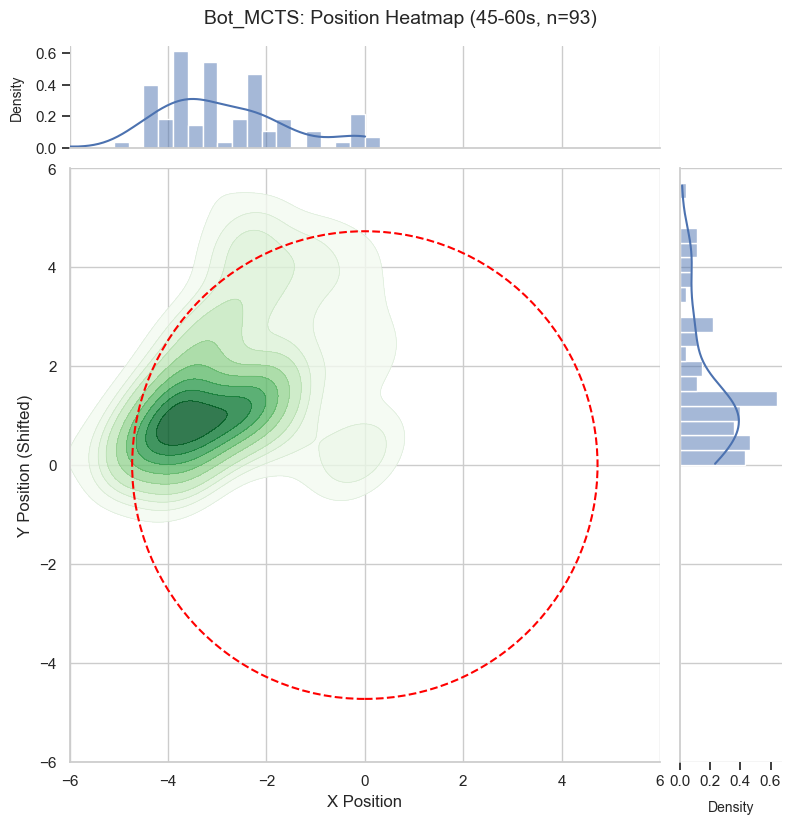


Generating Heatmaps for Bot_PRIMITIVE...
  Window 2.5-15s: n=138286


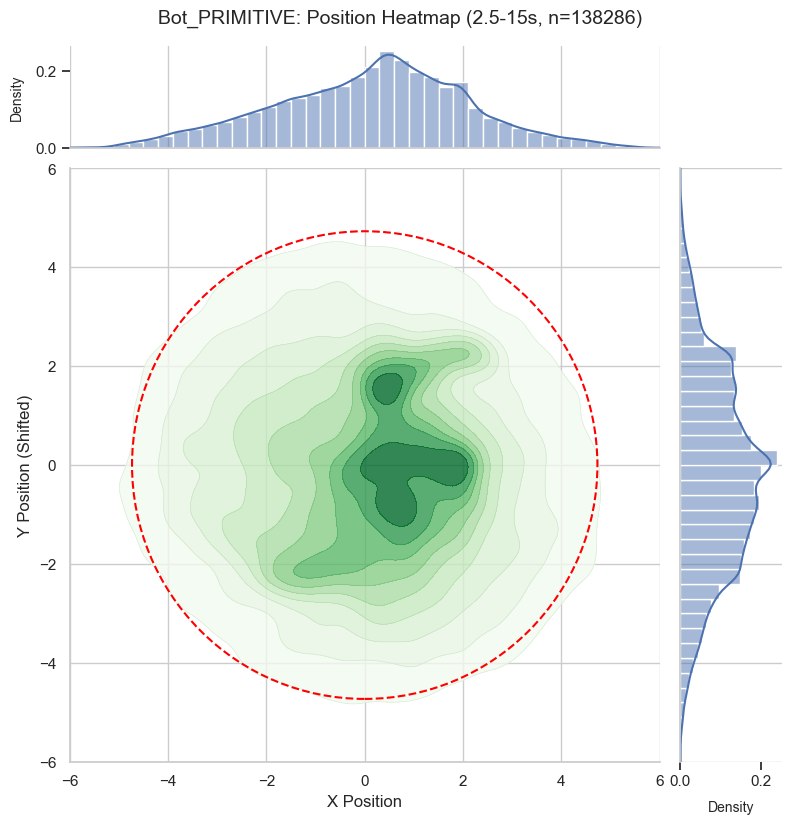

  Window 15-30s: n=14079


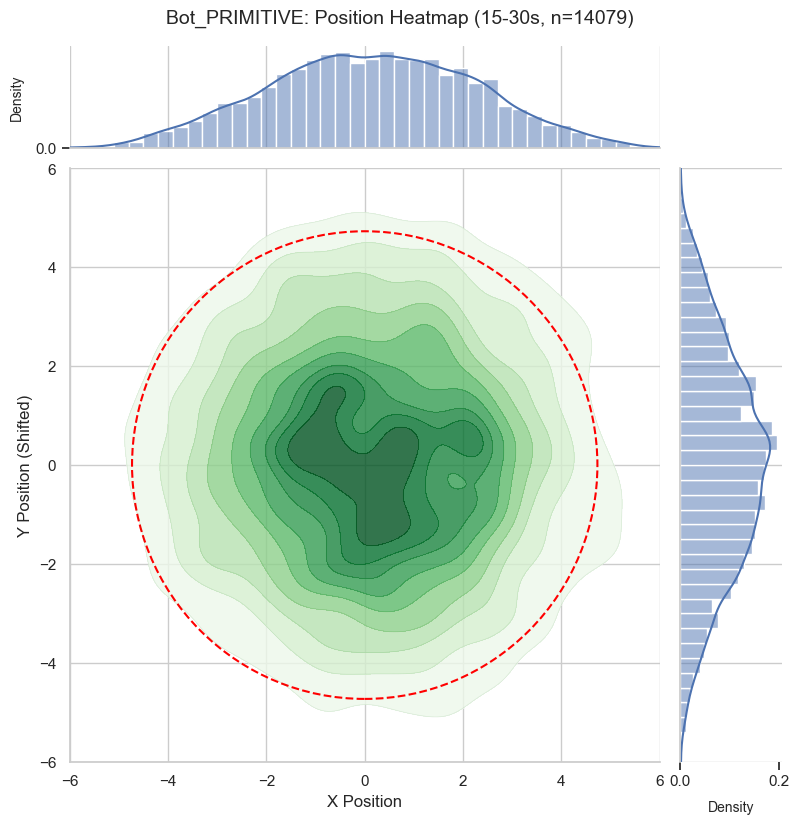

  Window 30-45s: n=873


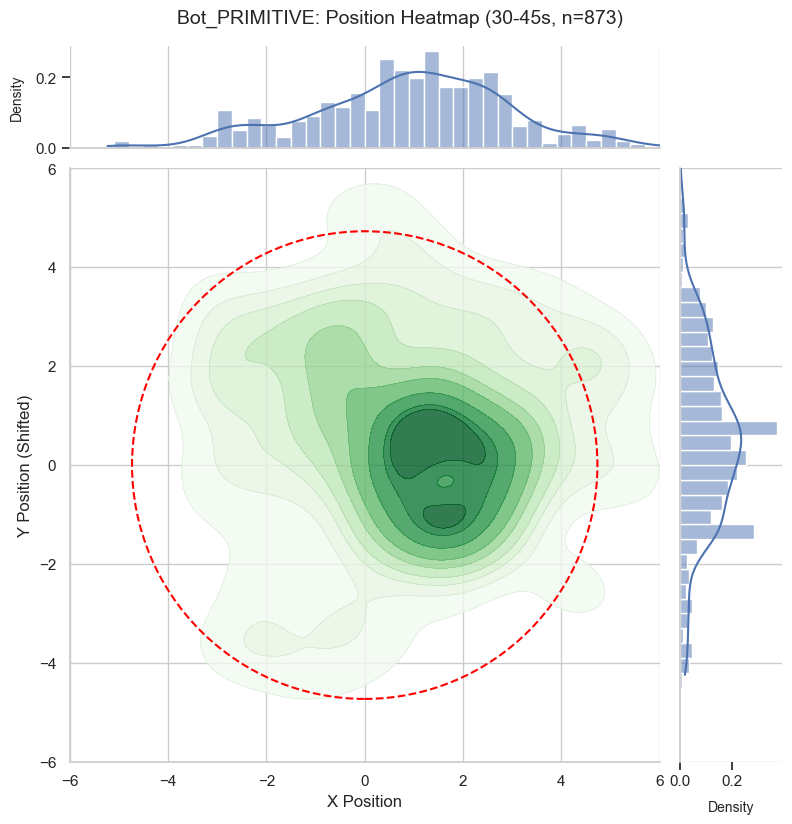

  Window 45-60s: n=251


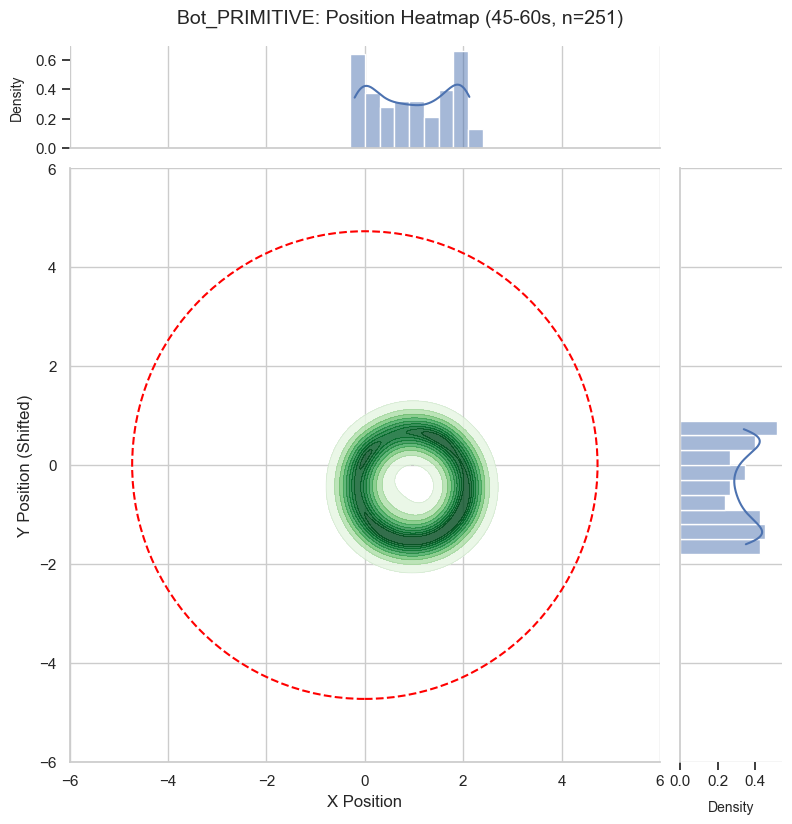

In [12]:
# Spatiotemporal Heatmaps Analysis
import matplotlib.ticker as ticker

if 'df_filtered' in locals() and 'target_bots' in locals():
    print("--- Spatiotemporal Heatmaps ---")
    
    # Define time windows
    time_windows = [(2.5, 15), (15, 30), (30, 45), (45, 60)]
    heatmap_range = (-6, 6)
    
    for bot in target_bots:
        print(f"\nGenerating Heatmaps for {bot}...")
        
        for t_start, t_end in time_windows:
            # Filter by time window
            window_data = df_filtered[
                (df_filtered["BotName"] == bot) & 
                (df_filtered["Event_StartedAt"] >= t_start) & 
                (df_filtered["Event_StartedAt"] < t_end)
            ]
            
            n_samples = len(window_data)
            
            if n_samples < 10:
                print(f"  Window {t_start}-{t_end}s: Not enough data (n={n_samples})")
                continue
            
            print(f"  Window {t_start}-{t_end}s: n={n_samples}")
            
            # Create JointGrid for Contour + Histogram
            g = sns.JointGrid(data=window_data, x="Robot_PosX", y="PosY_Shifted", height=8, xlim=heatmap_range, ylim=heatmap_range)
            
            # 1. Filled Contour (Greens)
            g.plot_joint(sns.kdeplot, fill=True, cmap="Greens", thresh=0.05, clip=heatmap_range, alpha=0.8)
            
            # 2. Outlines (Darker Green)
            g.plot_joint(sns.kdeplot, fill=False, color="darkgreen", linewidths=0.5, alpha=0.1, thresh=0.05, clip=heatmap_range)
            
            # 3. Marginals (Normalized Density)
            g.plot_marginals(sns.histplot, alpha=0.5, kde=True, stat="density", binrange=heatmap_range, bins=40)
            
            # 4. Axis Ticks and Labels for Histograms
            # --- Marginal X histogram (top): Density on Y ---
            g.ax_marg_x.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
            g.ax_marg_x.set_ylabel("Density", fontsize=10, labelpad=8)
            g.ax_marg_x.yaxis.set_label_position("left")
            g.ax_marg_x.yaxis.label.set_visible(True)
            g.ax_marg_x.tick_params(left=True, labelleft=True)

            # --- Marginal Y histogram (right): Density on X ---
            g.ax_marg_y.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
            g.ax_marg_y.set_xlabel("Density", fontsize=10, labelpad=8)
            g.ax_marg_y.xaxis.set_label_position("bottom")
            g.ax_marg_y.xaxis.label.set_visible(True)
            g.ax_marg_y.tick_params(bottom=True, labelbottom=True)

            # Set labels for main plot
            g.set_axis_labels("X Position", "Y Position (Shifted)")
            
            # Adjust layout to prevent title overlap
            g.fig.text(
                0.5, 1.0,
                f"{bot}: Position Heatmap ({t_start}-{t_end}s, n={n_samples})",
                ha="center",
                va="bottom",
                fontsize=14
            )
            
            # Add Arena boundaries (Circle)
            circle = plt.Circle((0, 0), 4.73, color='red', fill=False, linestyle='--', linewidth=1.5)
            g.ax_joint.add_patch(circle)
            
            plt.show()
else:
    print("Data not found. Please run the 'Position Distribution Analysis' cell first.")

Analyzing win/loss/draw for bots: ['Bot_BT', 'Bot_FSM', 'Bot_GA', 'Bot_MCTS', 'Bot_PRIMITIVE']

=== Debug: GameWinner values ===
GameWinner
2    1148985
1    1045357
0     894050
Name: count, dtype: int64

=== Debug: After mapping ===
GameWinner_Mapped
Draw     1148985
Right    1045357
Left      894050
Name: count, dtype: int64

=== Debug: Unique games ===
Total unique games: 3700

=== Debug: Wins per bot ===
WinnerBot
Bot_BT           1044
Bot_FSM           979
Bot_PRIMITIVE     533
Bot_MCTS          439
Bot_GA            191
Name: count, dtype: int64

Bot_BT: 1800 games, 1044 wins, 756 losses, 0 draws

Bot_FSM: 2500 games, 979 wins, 1007 losses, 514 draws

Bot_GA: 500 games, 191 wins, 309 losses, 0 draws

Bot_MCTS: 700 games, 439 wins, 261 losses, 0 draws

Bot_PRIMITIVE: 1000 games, 533 wins, 467 losses, 0 draws


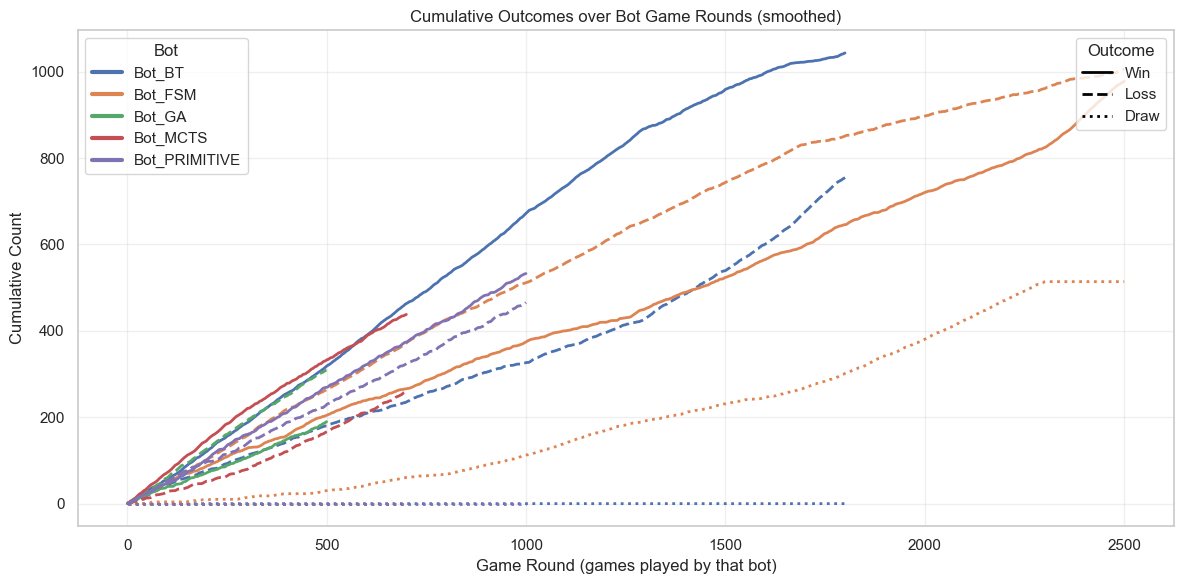

In [13]:
# === Cumulative Win/Loss/Draw over Bot Game Rounds (same plot, color=bot, linestyle=outcome, smoothed) ===
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

# Normalize bot names - remove trailing numbers (e.g., Bot_FSM_2 -> Bot_FSM)
def normalize_bot_name(bot_name):
    """Remove trailing numeric suffixes like _2, _3, etc."""
    if pd.isna(bot_name):
        return bot_name
    # Remove pattern like _2, _3, etc at the end
    return re.sub(r'_\d+$', '', str(bot_name))

# Apply normalization to merged_df
df = merged_df.copy()
df["Meta_LeftBot"] = df["Meta_LeftBot"].apply(normalize_bot_name)
df["Meta_RightBot"] = df["Meta_RightBot"].apply(normalize_bot_name)

# Get all unique bots from the normalized data
unique_left = set(df["Meta_LeftBot"].unique())
unique_right = set(df["Meta_RightBot"].unique())
bots = sorted(unique_left | unique_right)

print(f"Analyzing win/loss/draw for bots: {bots}\n")

# Parse timestamp for consistent game ordering
df["GameTimestamp_dt"] = pd.to_datetime(df["GameTimestamp"], format="%Y%m%d_%H%M%S", errors="coerce")

# Map GameWinner from simulation format (0=Left, 1=Right, 2=Draw) to expected format
# In your CSV: GameWinner can be 0, 1, or 2
print("=== Debug: GameWinner values ===")
print(df["GameWinner"].value_counts())

# Create proper winner mapping
df["GameWinner_Mapped"] = df["GameWinner"].map({0: "Left", 1: "Right", 2: "Draw"})

# Check if mapping worked
print("\n=== Debug: After mapping ===")
print(df["GameWinner_Mapped"].value_counts())

# Reduce to 1 row per game
sort_cols = [c for c in ["GameIndex", "GameTimestamp_dt"] if c in df.columns]
games = (
    df.sort_values(sort_cols)
      .drop_duplicates(subset=["BattleID"], keep="first")
      .reset_index(drop=True)
)

print(f"\n=== Debug: Unique games ===")
print(f"Total unique games: {len(games)}")

# Identify draw + winner bot
games["IsDraw"] = games["GameWinner_Mapped"] == "Draw"
games["WinnerBot"] = None
games.loc[games["GameWinner_Mapped"] == "Left",  "WinnerBot"] = games.loc[games["GameWinner_Mapped"] == "Left",  "Meta_LeftBot"]
games.loc[games["GameWinner_Mapped"] == "Right", "WinnerBot"] = games.loc[games["GameWinner_Mapped"] == "Right", "Meta_RightBot"]

# Debug: Check winner distribution per bot
print("\n=== Debug: Wins per bot ===")
print(games["WinnerBot"].value_counts())

# ---- Plot settings ----
outcomes = {
    "Win":  {"ls": "-",  "col": "_W"},
    "Loss": {"ls": "--", "col": "_L"},
    "Draw": {"ls": ":",  "col": "_D"},
}

smooth_span = 4  # increase for smoother, decrease for more faithful steps

# Assign one consistent color per bot using matplotlib default cycle
cycle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
bot_color = {b: cycle_colors[i % len(cycle_colors)] for i, b in enumerate(bots)}

plt.figure(figsize=(12, 6))

for b in bots:
    participated = (games["Meta_LeftBot"] == b) | (games["Meta_RightBot"] == b)
    bot_games = games[participated].copy()

    if bot_games.empty:
        print(f"[WARN] {b}: no games found.")
        continue

    # x-axis: games played by this bot
    bot_games["BotRound"] = range(1, len(bot_games) + 1)

    win  = (bot_games["WinnerBot"] == b)
    draw = (bot_games["IsDraw"])
    loss = (~win) & (~draw)

    bot_games[f"{b}_W"] = win.astype(int)
    bot_games[f"{b}_L"] = loss.astype(int)
    bot_games[f"{b}_D"] = draw.astype(int)

    # cumulative counts over bot rounds
    bot_games[f"{b}_W_cum"] = bot_games[f"{b}_W"].cumsum()
    bot_games[f"{b}_L_cum"] = bot_games[f"{b}_L"].cumsum()
    bot_games[f"{b}_D_cum"] = bot_games[f"{b}_D"].cumsum()

    # Debug output
    print(f"\n{b}: {len(bot_games)} games, {bot_games[f'{b}_W'].sum()} wins, {bot_games[f'{b}_L'].sum()} losses, {bot_games[f'{b}_D'].sum()} draws")

    # smooth (EWMA) for "smooth lines"
    W = bot_games[f"{b}_W_cum"].ewm(span=smooth_span, adjust=False).mean()
    L = bot_games[f"{b}_L_cum"].ewm(span=smooth_span, adjust=False).mean()
    D = bot_games[f"{b}_D_cum"].ewm(span=smooth_span, adjust=False).mean()

    # plot all outcomes for this bot (same color, different line styles)
    plt.plot(bot_games["BotRound"], W, outcomes["Win"]["ls"],  color=bot_color[b], linewidth=2)
    plt.plot(bot_games["BotRound"], L, outcomes["Loss"]["ls"], color=bot_color[b], linewidth=2)
    plt.plot(bot_games["BotRound"], D, outcomes["Draw"]["ls"], color=bot_color[b], linewidth=2)

plt.title("Cumulative Outcomes over Bot Game Rounds (smoothed)")
plt.xlabel("Game Round (games played by that bot)")
plt.ylabel("Cumulative Count")
plt.grid(True, alpha=0.3)

# Two legends: one for bot colors, one for outcome linestyles
bot_handles = [Line2D([0], [0], color=bot_color[b], lw=3, label=b) for b in bots]
out_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=outcomes["Win"]["ls"],  label="Win"),
    Line2D([0], [0], color="black", lw=2, linestyle=outcomes["Loss"]["ls"], label="Loss"),
    Line2D([0], [0], color="black", lw=2, linestyle=outcomes["Draw"]["ls"], label="Draw"),
]

leg1 = plt.legend(handles=bot_handles, title="Bot", loc="upper left")
plt.gca().add_artist(leg1)
plt.legend(handles=out_handles, title="Outcome", loc="upper right")

plt.tight_layout()
plt.show()

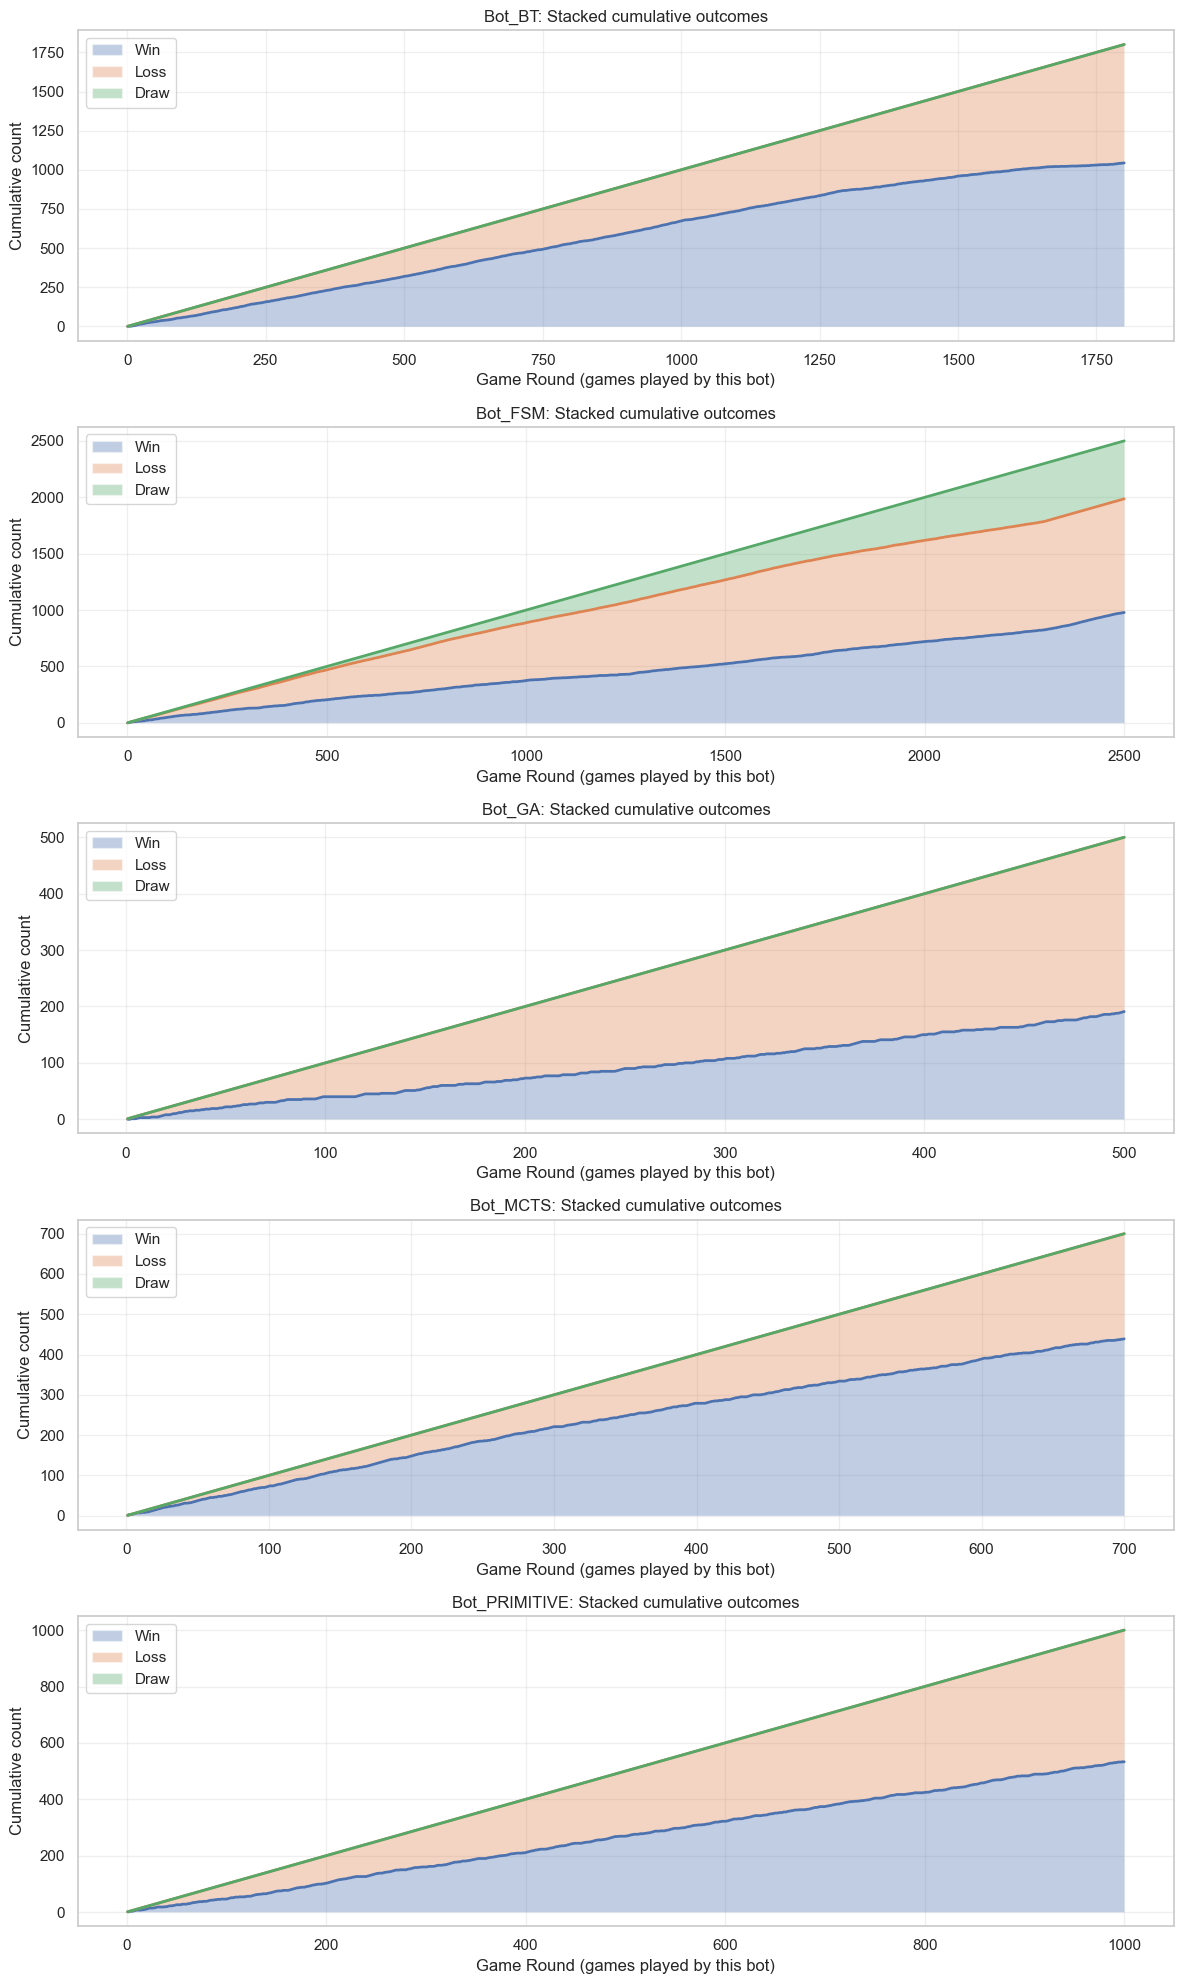

In [14]:
# === Stacked cumulative outcomes (Wins/Losses/Draws) per bot ===
import pandas as pd
import matplotlib.pyplot as plt
import re

# Normalize bot names - remove trailing numbers (e.g., Bot_FSM_2 -> Bot_FSM)
def normalize_bot_name(bot_name):
    """Remove trailing numeric suffixes like _2, _3, etc."""
    if pd.isna(bot_name):
        return bot_name
    # Remove pattern like _2, _3, etc at the end
    return re.sub(r'_\d+$', '', str(bot_name))

# Apply normalization to merged_df
df = merged_df.copy()
df["Meta_LeftBot"] = df["Meta_LeftBot"].apply(normalize_bot_name)
df["Meta_RightBot"] = df["Meta_RightBot"].apply(normalize_bot_name)

# Get all unique bots from the normalized data
unique_left = set(df["Meta_LeftBot"].unique())
unique_right = set(df["Meta_RightBot"].unique())
bots = sorted(unique_left | unique_right)

df["GameTimestamp_dt"] = pd.to_datetime(df["GameTimestamp"], format="%Y%m%d_%H%M%S", errors="coerce")

# Reduce to 1 row per game
sort_cols = [c for c in ["GameIndex", "GameTimestamp_dt"] if c in df.columns]
games = (
    df.sort_values(sort_cols)
      .drop_duplicates(subset=["BattleID"], keep="first")
      .reset_index(drop=True)
)

# Winner / draw mapping
games["GameWinner_Mapped"] = games["GameWinner"].map({0: "Left", 1: "Right", 2: "Draw"})
games["IsDraw"] = games["GameWinner_Mapped"] == "Draw"
games["WinnerBot"] = None
games.loc[games["GameWinner_Mapped"] == "Left",  "WinnerBot"] = games.loc[games["GameWinner_Mapped"] == "Left",  "Meta_LeftBot"]
games.loc[games["GameWinner_Mapped"] == "Right", "WinnerBot"] = games.loc[games["GameWinner_Mapped"] == "Right", "Meta_RightBot"]

# ---- Plot: one stacked chart per bot ----
fig, axes = plt.subplots(len(bots), 1, figsize=(12, 4 * len(bots)), sharex=False)
if len(bots) == 1:
    axes = [axes]

for ax, b in zip(axes, bots):
    participated = (games["Meta_LeftBot"] == b) | (games["Meta_RightBot"] == b)
    bot_games = games[participated].copy()

    if bot_games.empty:
        ax.set_title(f"{b} (no games found)")
        ax.axis("off")
        continue

    bot_games["BotRound"] = range(1, len(bot_games) + 1)

    win  = (bot_games["WinnerBot"] == b)
    draw = (bot_games["IsDraw"])
    loss = (~win) & (~draw)

    bot_games["W_cum"] = win.astype(int).cumsum()
    bot_games["L_cum"] = loss.astype(int).cumsum()
    bot_games["D_cum"] = draw.astype(int).cumsum()

    x = bot_games["BotRound"].to_numpy()
    W = bot_games["W_cum"].to_numpy()
    L = bot_games["L_cum"].to_numpy()
    D = bot_games["D_cum"].to_numpy()

    # Stacked cumulative areas:
    # base 0..W (wins), then W..W+L (losses), then W+L..W+L+D (draws)
    ax.fill_between(x, 0,   W,         alpha=0.35, label="Win")
    ax.fill_between(x, W,   W + L,     alpha=0.35, label="Loss")
    ax.fill_between(x, W+L, W + L + D, alpha=0.35, label="Draw")

    # Optional outlines (stacked "lines")
    ax.plot(x, W,           linewidth=2)
    ax.plot(x, W + L,       linewidth=2)
    ax.plot(x, W + L + D,   linewidth=2)

    ax.set_title(f"{b}: Stacked cumulative outcomes")
    ax.set_xlabel("Game Round (games played by this bot)")
    ax.set_ylabel("Cumulative count")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()